<a href="https://colab.research.google.com/github/anastasiiaCher/python-for-DPaV/blob/main/labs/%D0%9B%D0%A03_%D0%9E%D0%B1%D0%B5%D1%81%D0%BF%D0%B5%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BA%D0%B0%D1%87%D0%B5%D1%81%D1%82%D0%B2%D0%B0_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Постановка задачи


**Цель работы:** исследование и обработка данных для повышения их качества.

**Краткое описание:** в лабораторной работе приводится поэтапный план изучения и обработки намеренно не предобработанных данных. Необходимо выполнить все этапы плана и оценить результаты преобразований.

# Данные



В папке [Data/lab3](https://drive.google.com/drive/folders/1437z7m5Ut4WUJOhJg1oZz13dtBpxgFKs?usp=share_link) расположена таблица `monster_com_job_sample.com` с данными о вакансиях. Также эти данные с описанием и примерами обработки можно найти на [kaggle](https://www.kaggle.com/code/ankkur13/perfect-dataset-to-get-the-hands-dirty/data#).

##### **Формат данных**

```
country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
United States of America,US,"",No,jobs.monster.com,"TeamSoft is seeing an IT Support Specialist to join our client in Madison, WI. The ideal candidate must have at least 6 years of experience in the field. They need to be familiar with a variety of the field's concepts, practices, and procedures as this position relies on extensive experience and judgment to plan and accomplish goals. Required Skills:вАҐ Call tracking softwareвАҐ Phone based technical supportвАҐ Problem documentation and communicationвАҐ Remote Desktop Management ToolsвАҐ Respond to customer requestsвАҐ General understanding of LANDeskвАҐ Microsoft Office 2007 SuiteFind out why TeamSoft is the Madison area's technology leader with over 200 IT consultants. Owned, operated, and managed by IT consultants, TeamSoft is the clear choice for your career. Join the TeamSoft family today!Did you know?вАҐ TeamSoft offers salaried options for many positions that include 5 weeks PTO and great benefits!вАҐ TeamSoft has been in business since 1996вАҐ TeamSoft's owners are local IT professionals who possess a wealth of experience in application development, business analysis, and project managementвАҐ TeamSoft's Recruiters are knowledgeable, friendly, and ready to help you make your next great career moveвАҐ TeamSoft offers a full benefits suite to all of our W2 consultants, including a 401k plan with a 100% vested 4% dollar for dollar matchвАҐ Our targeted selection process is designed to get to know your strengths and career interests and provide you with the best chance for success in your new positionвАҐ Our longest running consultant has been with us for 16 yearsвАҐ Consultants can participate in our charitable giving committee. To date, TeamSoft's charitable giving committee has donated over $100,000!TeamSoft is owned by local IT professionals. Our team also has deep experience with IT staffing. Our clients understand this and rely on our expertise. That is why TeamSoft is the Madison Area's largest privately owned IT consulting firm, with more than 200 current consultants! With over 50 active clients, TeamSoft will give you the greatest exposure to the widest range of IT careers.Our owners possess a combined 60+ years of IT consulting experience. Our recruiting and Account Management staff are very well-versed in our client markets. We get you. We know you. We know what you do every day. And we know what you deal with on the job.You take your career seriously and so do we. At TeamSoft you are not just a resume or number. Our goal is to create long-term partnerships with each of our consultants, and according to feedback from many of them, we are very good at this. Click HERE to see what our consultants have to say about working with TeamSoft.TeamSoft -- Promote yourself!TeamSoft is an equal employment opportunity employer functioning under an Affirmative Action Plan.",IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702","",http://jobview.monster.com/it-support-technician-job-madison-wi-us-167855963.aspx?mescoid=1500134001001&jobPosition=20,"",IT/Software Development,11d599f229a80023d2f40e7c52cd941e
United States of America,US,"",No,jobs.monster.com,"The Wisconsin State Journal is seeking a flexible and motivated reporter/editor to lead its three-person business desk. WeвАЩre looking for an experienced journalist able to spot trends, be a watchdog and reflect the Madison areaвАЩs vibrant entrepreneurial community. This is a hybrid reporting and editing position that calls for a fleet-footed, multimedia storyteller able to maximize the newspaperвАЩs online presentation while also editing two sections a week. Candidates must have strong news judgment, be well versed in business news and trends and be able to quickly prioritize coverage.At least five yearsвАЩ experience reporting or editing for digital and print platforms desired. To be considered for the position, applicants must apply online.¬†As part of your online application, please attach five samples of your work or links to five recent stories.Wisconsin State Journal, 1901 Fish Hatchery Road, Madison, WI 53713Affirmative Action/Equal Opportunity Employer/Pre-employment drug testing appliesPI94338362Apply Here",Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-editor-job-madison-wi-us-167830105.aspx?mescoid=2700437001001&jobPosition=7,"","",e4cbb126dabf22159aff90223243ff2a
...
```

##### **Описание полей**
 - ```country``` — наименование страны;
 - ```country_code``` — код страны;
 - ```date_added``` — дата размещения вакансии;
 - ```has_expired``` — актуальность вакансии;
 - ```job_board``` — агрегатор вакансий, с которого собраны данные;
 - ```job_description``` — описание вакансии;
 - ```job_title``` — наименование должности;
 - ```job_type``` — вид занятости;
 - ```location``` — метоположение организации;
 - ```organization``` — наименование организации;
 - ```page_url``` — ссылка на страницу с вакансией;
 - ```salary``` — заработная плата;
 - ```sector``` — сфера деятельности;
 - ```uniq_id``` — уникальный идентификатор записи о вакансии.

# Понимание данных

In [831]:
import re
import numpy as np
import pandas as pd
import missingno as msno
from matplotlib import pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings("ignore")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [832]:
sns.set_style('darkgrid',{'axes.grid' : True})

В датасете есть несколько столбцов, в каждой ячейке которых записано одно и то же значение. Есть столбцы, в которых формат записи значений не стандартизирован. А есть такие, где указана информация, не соответствующая названию столбца.

**Первый этап изучения данных** – понять, какие основные проблемы предстоит решить для каждого из столбцов. Для этого загрузите датасет и выведите случайные несколько строк из него. Постарайтесь понять, что из себя представляют данные в столбцах.

In [833]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/files/monster_com_job_sample.csv")
df.sample(15)

,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
15244,United States of America,US,NaN,No,jobs.monster.com,Report this job About the Job HIRING FULL-TIME...,Clysar LLC Job Application for Inspector Mater...,"Full Time, Employee",Address WFD Job Orders 902 West Kimberly Rd Su...,Manufacturing - Other,http://jobview.monster.com/inspector-material-...,NaN,NaN,e544f29d323b6beda4deef6a8d145f8c
7182,United States of America,US,NaN,No,jobs.monster.com,Recognized by Inavero as a Best in Staffing or...,Account Manager - Account Manager/Technical Re...,Full Time Employee,"Norcross, GA 30092",NaN,http://jobview.monster.com/account-manager-acc...,"40,000.00 - 60,000.00 $ /year",NaN,8a1037e355a4ec8338bc1b34de9befaa
16907,United States of America,US,NaN,No,jobs.monster.com,Report this job About the Job CA SiteMinder/CA...,Monster,"Full Time, Employee",CA SiteMinder/CA Directory Expert Department: ...,Computer/IT Services,http://jobview.monster.com/ca-siteminder-ca-di...,NaN,NaN,a21162c23a324a59a5d3d732fc9ae070
354,United States of America,US,NaN,No,jobs.monster.com,Head of Oncology Business Development and Lice...,Head of Oncology Business Development and Lice...,"Full Time, Employee","Cambridge , MA",Biotechnology/Pharmaceuticals,http://jobview.monster.com/head-of-oncology-bu...,NaN,General/Other: Business/Strategic Management,962a1e8b2f0d12e43ca4bb024d618f9f
19545,United States of America,US,NaN,No,jobs.monster.com,We would will like to Invite you to our Job Fa...,Barista and Crew Leaders ~ Starbucks Job in Miami,Full Time Employee,"Miami, FL",NaN,http://jobview.monster.com/Barista-Crew-Leader...,NaN,Food Services/Hospitality,e7ec151a024189eb6272e0b1d93b272e
3577,United States of America,US,NaN,No,jobs.monster.com,Join our dedicated team!Vision Forward Associa...,Pediatric Occupational Therapist,Per Diem,"Milwaukee, WI 53213",Nonprofit Charitable Organizations,http://jobview.monster.com/Pediatric-Occupatio...,NaN,Experienced (Non-Manager),f18bbccd5491a3726e1dbbb4e03454a4
20558,United States of America,US,NaN,No,jobs.monster.com,<!-- /* Font Definitions */ @font-face {font...,Momentum LLC Job Application for Sr. Java Deve...,NaN,<!-- /* Font Definitions */ @font-face {font...,NaN,http://jobview.monster.com/sr-java-developer-r...,NaN,NaN,db5cbf6b6a926dcd8c0dff85f073fe7b
284,United States of America,US,NaN,No,jobs.monster.com,Systems Admin (T&E)Job Description:· Th...,Jr. Systems Administrator (Travel & Expense) J...,"Full Time, Temporary/Contract/Project","Clifton, OH 45220",Computer/IT Services,http://jobview.monster.com/jr-systems-administ...,13.00 - 16.00 $ /year,Administrative/Clerical,ff0a14d110ed158f7177fd3f7442689d
6614,United States of America,US,NaN,No,jobs.monster.com,Multiple openings for Superintendents and Trav...,Traveling Superintendent- Multifamily Construc...,"Full Time , Employee","Orlando, FL",NaN,http://jobview.monster.com/traveling-superinte...,"100,000.00 - 130,000.00 $ /year",NaN,78b8799e0b627de4cb2bc7072b785cec
12413,United States of America,US,NaN,No,jobs.monster.com,Full-TimeCincinnati Circulating Licensed Pract...,Licensed Practical Nurse LPN Job in Cincinnati,Full Time Employee,"Cincinnati, OH 45236",Healthcare Services Other/Not Classified,http://jobview.monster.com/licensed-practical-...,NaN,Medical/Health,61511822e556c49b2b81e1709ab16f6a


#### Исследование датасета

In [834]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          22000 non-null  object
 1   country_code     22000 non-null  object
 2   date_added       122 non-null    object
 3   has_expired      22000 non-null  object
 4   job_board        22000 non-null  object
 5   job_description  22000 non-null  object
 6   job_title        22000 non-null  object
 7   job_type         20372 non-null  object
 8   location         22000 non-null  object
 9   organization     15133 non-null  object
 10  page_url         22000 non-null  object
 11  salary           3446 non-null   object
 12  sector           16806 non-null  object
 13  uniq_id          22000 non-null  object
dtypes: object(14)
memory usage: 2.3+ MB


In [835]:
df["country"].unique(), df["country_code"].unique()

(array(['United States of America'], dtype=object),
 array(['US'], dtype=object))

In [836]:
df["has_expired"].unique()

array(['No'], dtype=object)

In [837]:
df["job_board"].unique()

array(['jobs.monster.com'], dtype=object)

In [838]:
df["page_url"].str.extract(r'http://(.*?)\.com').value_counts()

,count
0,
jobview.monster,21329
jobview.local-jobs.monster,629
job-openings.monster,40
jobview.timesdaily.monster,1
www.monster,1


In [839]:
df["uniq_id"].value_counts()

,count
uniq_id,
1d37a888ca65fd919e459147a4c33457,1
be751bfda9b5bd95ab7ea952ae7b99f7,1
a53be963aac0a938a50a4d4cf7bc3ca3,1
6b14e0129a4841c3cf9999ef93d146c6,1
ec69c76dc680a91376603b53ad7b0486,1
...,...
64d0272dc8496abfd9523a8df63c184c,1
58435fcab804439efdcaa7ecca0fd783,1
839106b353877fa3d896ffb9c1fe01c0,1


In [840]:
df[~df["salary"].isna()]["salary"].sample(20)

,salary
19068,"70,000.00 - 90,000.00 $ /year"
4754,"65,000.00 - 69,000.00 $ /year"
4974,50.00 - 55.00 $ /year
9075,"85,000.00 - 95,000.00 $ /yearalong with a phen..."
6140,"100,000.00 - 120,000.00 $ /yearpackage"
9201,Commensurate with Experience
4557,30.00 - 42.00 $ /hour
8033,Nurse Supervisor- $3000 Sign-On Bonus
9515,18.00 - 20.00 $ /hour
17271,20.00 - 25.00 $ /hour


In [841]:
df[df["location"].str.match(r"\w+, [A-Z]{2},?( \d{5})?")]["location"]

,location
0,"Madison, WI 53702"
1,"Madison, WI 53708"
3,"Dixon, CA"
4,"Camphill, PA"
5,"Charlottesville, VA"
...,...
21995,"Cincinnati, OH"
21996,"Cincinnati, OH 45236"
21997,"Chicago, IL 60602"
21998,"Chicago, IL 60609"


In [842]:
df[df["location"].str.match(r".*\d{5}.*")]["location"]

,location
0,"Madison, WI 53702"
1,"Madison, WI 53708"
7,"Austin, TX 73301"
8,"Austin, TX 78746"
10,"Berryville, VA 22611"
...,...
21993,"Chicago, IL 60603"
21994,"Cincinnati, OH 45202"
21996,"Cincinnati, OH 45236"
21997,"Chicago, IL 60602"


In [843]:
df[~df["location"].str.contains(",")]["location"]

,location
6,Contact name Tony Zerio
16,Wadesboro 28170
22,La Porte 46350
38,Bi-Lingual Editorial Strategist
73,Quality Engineer
...,...
21818,Location:
21889,Position Information
21933,Location:
21967,Location:


In [844]:
df[~df["organization"].isna()]["organization"].value_counts().iloc[:20]

,count
organization,
Healthcare Services,1919
All,1158
Retail,1081
Other/Not Classified,1048
Manufacturing - Other,885
Computer/IT Services,822
Legal Services,466
Business Services - Other,410
Restaurant/Food Services,384


In [845]:
df[~df["organization"].isna()]["organization"].value_counts().iloc[-30:]

,count
organization,
"Chamblee, GA 30326",1
"Rockford, IL 61101",1
Real Estate/Property ManagementRental ServicesAccounting and Auditing Services,1
AllInsuranceReal Estate/Property Management,1
Staffing/Employment AgenciesOther/Not Classified,1
Telecommunications Services Computer Software Computer/IT Services,1
Biotechnology/PharmaceuticalsComputer/IT Services,1
Barrow Industries,1
BankingBusiness Services - OtherFinancial Services,1


In [846]:
df[~df["sector"].isna()]["sector"].sample(20)

,sector
17908,Experienced (Non-Manager)
10323,Marketing/Product
2146,Other
6571,Education/Training
5056,Entry Level
7779,Experienced (Non-Manager)
13943,General/Other: Quality Assurance/Safety
4315,Sales/Retail/Business Development
9499,Manufacturing/Production/Operations
9071,Experienced (Non-Manager)


In [847]:
df[(~df["sector"].isna()) & (~df["organization"].isna())][["organization", "sector"]].sample(20)

,organization,sector
10148,Manufacturing - Other,Manufacturing/Production/Operations
18333,Insurance,Sales/Retail/Business Development
17657,"Computer Software, Computer/IT Services",Customer Support/Client Care
3627,Accounting and Auditing Services,IT/Software Development
1592,Manufacturing - Other,Experienced (Non-Manager)
5065,"Mifflin, OH 43085",IT/Software Development
5068,All,Experienced (Non-Manager)
17523,Hotels and Lodging,Experienced (Non-Manager)
4757,Retail,Project/Program Management
20382,AllTelecommunications ServicesAutomotive Sales...,Sales/Retail/Business Development


In [848]:
df["job_title"].sample(20)

,job_title
15191,Help Desk Support - Job in Oxnard
1536,The Woodrow Wilson National Fellowship Foundat...
11508,Staff Accountant Job in Fort Lauderdale
16221,SENIOR CORPORATE FINANCIAL ANALYST Job in Las ...
14519,PERSONAL INJURY ATTORNEY Job in New Brunswick
20359,Senior .Net Developer Job in Knoxville
9079,HVAC Service Technician Job in Wheeling funct...
11084,ALL IN ONE Employment Services Job Application...
13232,Adminisrative Manager Job in Bronx
1987,Customer Support/Customer Service Representati...


In [849]:
len(df[df["job_title"].str.contains(" in ")])

18994

In [850]:
df[~df["job_title"].str.contains(" in ")]["job_title"].sample(20)

,job_title
10649,Case Manager RN or LMSW Kindred Hospital Haver...
6722,SAGA Fellow
12329,Recruiter
21585,Lead Sales Specialist
3922,Director
16736,Lead Software Product Manager - Palo Alto
3895,Monster
1406,Macy's **Seasonal Holiday Retail Receiving** M...
13818,Manager
21453,Dispatcher


In [851]:
df["job_type"].value_counts()

,count
job_type,
Full Time,6757
Full Time Employee,6617
"Full Time, Employee",3360
Full Time Temporary/Contract/Project,1062
"Full Time, Temporary/Contract/Project",533
"Full Time , Employee",406
Part Time Employee,382
Part Time,329
"Part Time, Employee",196


In [852]:
df["job_description"].sample(20)

,job_description
17331,If you’re a recent college grad looking for ha...
12013,One of our direct client is looking for Busine...
9772,Come and work for the leading manufacturer of ...
10279,"Targeted Pet Treats LLC (affiliate of APN, LLC..."
17414,Details:Job OverviewThe purpose of this positi...
7292,TRC has an immediate need for a Security Analy...
21951,About Aramark Aramark (NYSE: ARMK) is in the c...
20480,Aflac Insurance Sales Agent While a career in ...
20491,Report this job About the Job Job Area: Inform...
13928,Interesting QUALITY MANAGER opportunity at a h...


#### Задание

Составьте таблицу, в которой будет содержаться название столбца, тип данных в нем и краткое описание проблем, которые вы заметили при первом взгляде на данные.


Название столбца | Тип данных | Проблемы
--- | --- | ---
```country``` | string | Одно значение. Избыточно при наличии ```country_code```
```country_code``` | string | Одно значение. Избыточно при наличии ```country```
```date_added``` | date | Почти пустой столбец. 0.5% значений - не Nan
```has_expired``` | bool | Одно значение. Не имеет смысла, поскольку неактивные вакансии и так не будут показаны пользователям
```job_board``` | string | Одно значение. В рамках датасета может быть представлено как метаинформация
```job_description``` | string | Данные не привести к одному формату. Также содержатся данные из других столбцов (зарплата, локация, название професии). Содержит сырой текст, содержащий различные пробельные символы, не разбитый на логические блоки и тд
```job_title``` | string | В 86% записей есть указание локации вакансии. Также есть и лишняя информация (например, ```Monster```, ```Please apply only if you are qualified.```, ```No CDL? No Problem! We Train``` и другие). Еще иногда встречается куски кода сайта
```job_type``` | string | Одинаковые по смысле данные записаны в разных форматах, например, ```Part Time Employee``` и ```Part Time```
```location``` | string | Данные не поддлежат одному формату. Из трех "определителей" локации, города, кода штата и кода FIPS, могут присутствовать не все. Также присутствует лишняя информация, например, название профессии
```organization``` | string | Чаще здесь указан сектор, сфера компании, предлагающей вакансию, а не ее название. Непонятно, как соотносить со сектором в ``sector```. Присутствует информацияиз других столбцов (например, локация)
```page_url``` | string | Явных проблем нет, ссылки везде корректные. Все ссылки связаны с monster, но берутся с разных сайтов, из-за чего может быть проблема в неоднотипности полей с информацией на самих сайтах (надо проверять)
```salary``` | string | Данные не однотипны. Указывается как почасовая зарплата, так и за год. 84% значений в столбце пропущено, а среди непустых значений есть значения типа ```We offer competitive salary and benefits```, несущие не больше смысла, чем NaN
```sector``` | string | Сложно привести в одному формату. Также непонятно, как соотнести с сектором, указанным в ```organization``` (часто различаются)
```uniq_id``` | string | Проблем нет (значения действительно уникальные). Не имеет смысла, если есть индекс

### Оценка пустых ячеек в датасете

Выясните, в каких столбцах, строках и в каком количестве отсутствуют данные:
1. С помощью модуля `pandas` составьте таблицу, где каждому названию столбца будет сопоставлено общее количество ячеек и количество пустых ячеек.
2. Подсчитайте количество строк датасета, в которых пустыми являются более 75% ячеек.
3. Визуализируйте число пропусков в датасете с помощью модуля, построив столбчатую диаграмму. Для удобства можно воспользоваться модулем `missingno`.


In [853]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          22000 non-null  object
 1   country_code     22000 non-null  object
 2   date_added       122 non-null    object
 3   has_expired      22000 non-null  object
 4   job_board        22000 non-null  object
 5   job_description  22000 non-null  object
 6   job_title        22000 non-null  object
 7   job_type         20372 non-null  object
 8   location         22000 non-null  object
 9   organization     15133 non-null  object
 10  page_url         22000 non-null  object
 11  salary           3446 non-null   object
 12  sector           16806 non-null  object
 13  uniq_id          22000 non-null  object
dtypes: object(14)
memory usage: 2.3+ MB


In [854]:
missing_cells_75prcnt = len(df[df.isna().sum(axis=1) >= 0.75 * len(df.columns)])
print(f"Строк, где пропущено 75% и больше значений - {missing_cells_75prcnt}")

Строк, где пропущено 75% и больше значений - 0


In [855]:
max_missing_cells = df.isna().sum(axis=1).max() / len(df.columns) * 100
print(f"Максимально в строке пропущено {max_missing_cells}% значений")

Максимально в строке пропущено 35.714285714285715% значений


<Axes: >

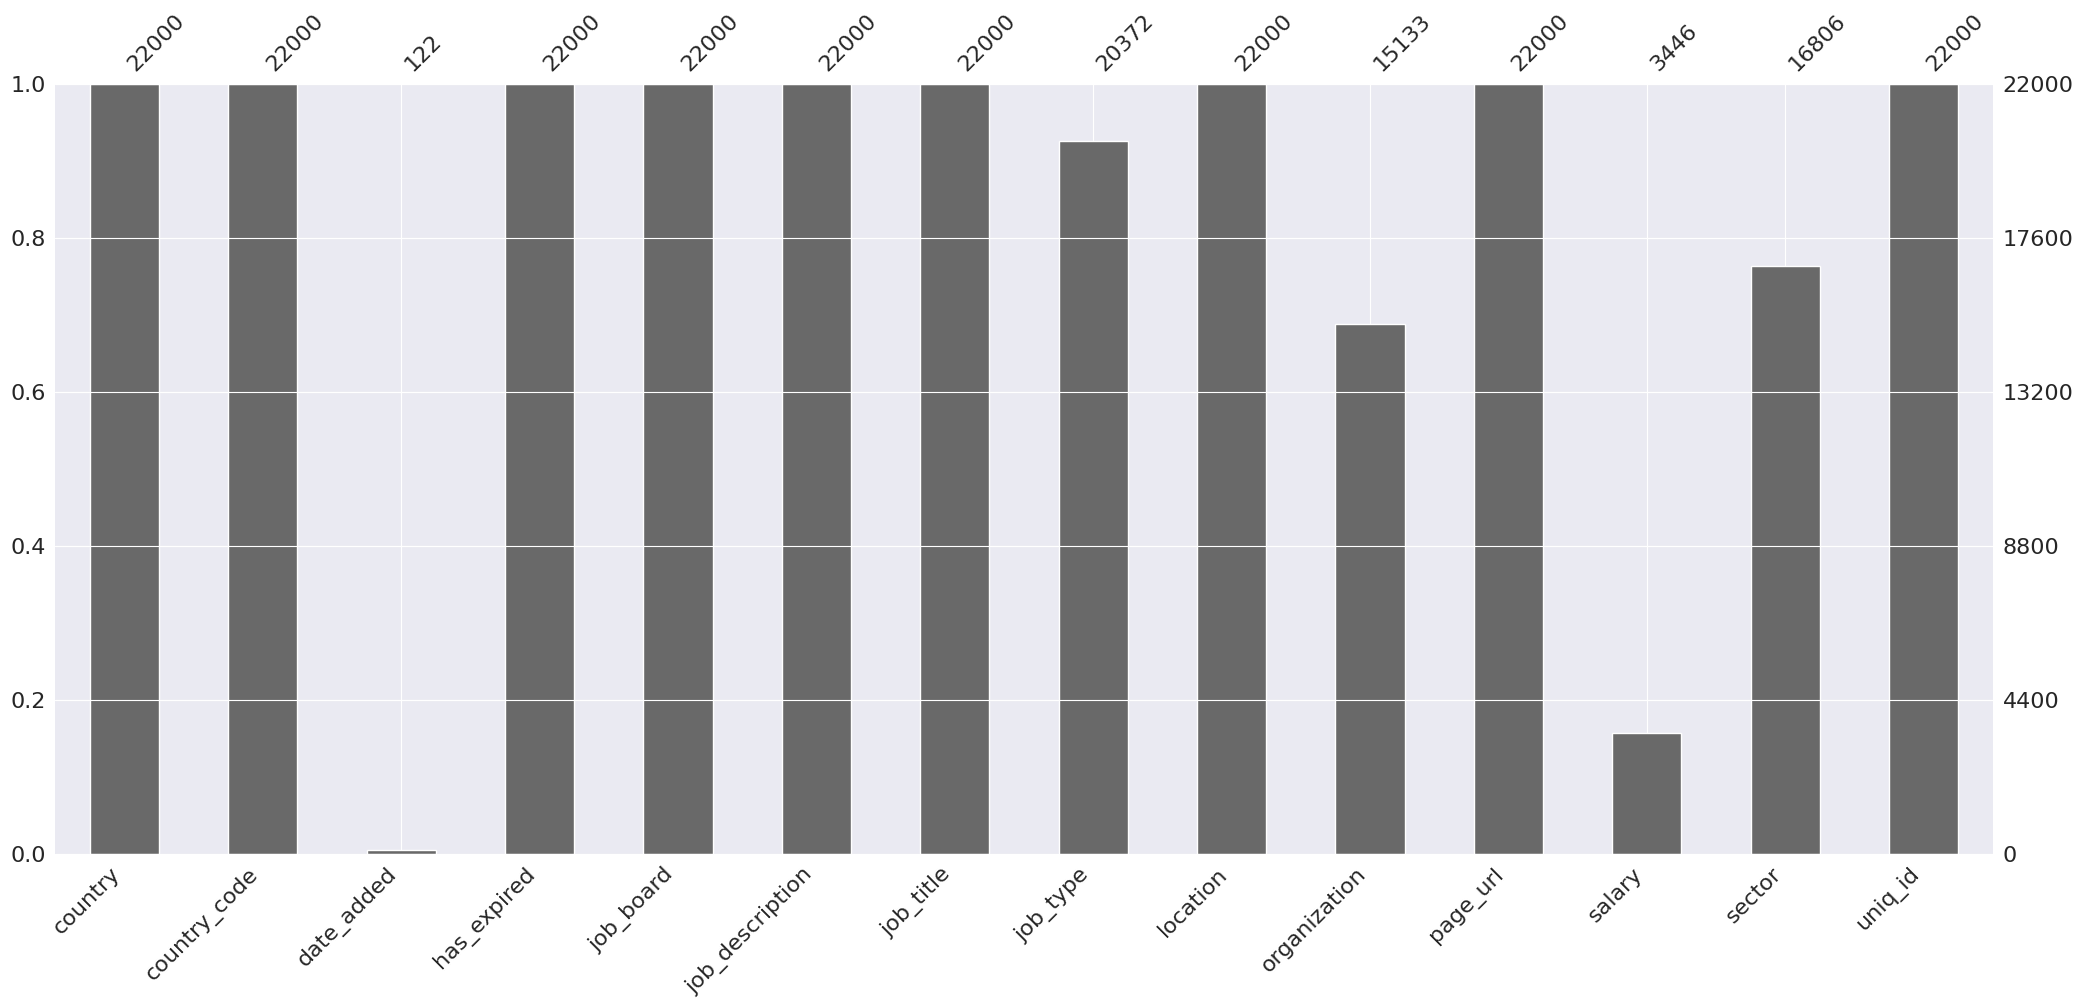

In [856]:
msno.bar(df)

Проверьте, как изменится размер датасета, если принять решение удалить все строки, где есть пустые значения. Сделайте выводы.

In [857]:
len(df[~df.isna().any(axis=1)])

5

Если удалить все строки, где есть пустые значения, строк останется всего 5, что очень мало для какой-либо дальнейшей работы с этими данными. Столбец ```date_added```, в целом, можно удалить, поскольку в нем слишком мало непустых значений (и сама дата создания вакансии на сайте мало что может сказать как о вакансии, так и об организации). Пропуски в остальных столбцах можно попытаться восстановить, например, из столбца ```job_desctiption```, который часто содержит избыточную для описания вакансии информацию (и зарплату, и тип занятости). ```sector``` и ```organization``` оба содержат сектор, их можно попытаться объединить, а непосредственно компанию, создавшую вакансию, вынести в отдельный столбец (или, в зависимости от задачи, не сохранять эту информацию). В итоге стоит сохранить как можно больше данных, чтобы на их основе можно было создать рабочую модель

### Первичная оценка данных в столбцах

Изучите данные в столбцах датасета, ответив на следующие вопросы:

**1. Есть ли столбцы, в которых встречается всего одно значение? Как их можно использовать в анализе?**

In [858]:
print(*[(i, df[i].iloc[0]) for i in df.columns if df[i].nunique() == 1], sep="\n")

('country', 'United States of America')
('country_code', 'US')
('has_expired', 'No')
('job_board', 'jobs.monster.com')


По одному значению содержат столбцы ```country```, ```country_code```, ```has_expired``` и ```job_board```. Столбец ```has_expired``` не несет смысла - пользователи на сайте агрегатора вакансий и так видят только актуальные вакансии. ```country``` и ```country_code``` между собой однозначно сопоставляются, поэтому один из столбцов (например, country_code) можно удалить. Значения в ```country``` и ```job_board``` можно считать метаинформацией датасета, и все выводы, сделанные на основе данных этого датасета, будут относиться только к США и только к агрегатору вакансий job.monster.com

**2. Есть ли такие значения, которые встречаются более чем в одном столбце?**

In [859]:
df["uniq_id"].nunique(), len(np.unique(df.index))

(22000, 22000)

In [860]:
df["country"].iloc[0], df["country_code"].iloc[0]

('United States of America', 'US')

In [861]:
df["job_board"].iloc[0], np.unique(df["page_url"].str.extract(r'http://(.*?)\.com')).tolist()

('jobs.monster.com',
 ['job-openings.monster',
  'jobview.local-jobs.monster',
  'jobview.monster',
  'jobview.timesdaily.monster',
  'www.monster'])

In [862]:
df[(~df["sector"].isna()) & (~df["organization"].isna()) & (df["sector"].str.lower().str.contains("retail"))][["organization", "sector"]].sample(5)

,organization,sector
8738,Retail,Sales/Retail/Business Development
21644,Manufacturing - Other,Sales/Retail/Business Development
18331,Retail,Sales/Retail/Business Development
7824,InsuranceOther/Not Classified,Sales/Retail/Business Development
21875,Retail,Sales/Retail/Business Development


In [863]:
df[(df["job_title"].str.contains(" in "))][["job_title", "location"]].sample(5)

,job_title,location
18404,buyer Job in Carneys Point,"Carneys Point, NJ"
3892,Event Specialist Part Time Sales Job in Knoxville,"Knoxville, TN"
12817,Shift Supervisor Job in Camphill,"Camphill, PA"
3260,Registered Nurse RN Job in Prospect Heights,"Prospect Heights, IL 60070"
14257,Maintenance Technician - Mechanical Equipment/...,"Atlanta, GA 30306"


In [864]:
df[df["job_description"].str.lower().str.contains("job title")][["job_title", "job_description"]].head(5)

,job_title,job_description
49,Technical Writer Job in Franklin Lakes,Job Title: Technical Writer Location: Franklin...
97,Personal Banker (SAFE) Bear Valley Job in Denver,Job Title: Personal Banker (SAFE) 1 - Bear Val...
150,Underwriter/Portfolio Officer Job in Pasadena,Job Title Underwriter/Portfolio Officer Job De...
198,Personal Banker (SAFE) Cypress Area Overhire ...,Job Title: Personal Banker (SAFE) 1 - Cypress ...
217,Personal Banker (SAFE) th Street Job in Denver,Job Title: Personal Banker (SAFE) 1 - 17th Str...


In [865]:
df_salary_check = df[(df["job_description"].str.contains(r"(\$\d+,\d+)")) & (~df["salary"].isna())]
df_salary_check.agg({"job_description": lambda x: x.str.extract(r"(\$\d+,\d+)"), "salary": lambda x: x}).sample(10)

,job_description,salary
,0,salary
17099,"$44,000","0.00 - 47,000.00 $ /year"
8350,"$63,400","63,400.00 - 86,858.00 $ /year"
14318,"$75,000","75,000.00 - 90,000.00 $ /year"
10641,"$31,865",$15.32+ /hour
11324,"$42,000","42,000.00 - 55,000.00 $ /year"
15189,"$1,878","1,878.00 - 1,878.00 $ /month"
19952,"$40,000","40,000.00 - 50,000.00 $ /year"
20451,"$40,000","40,000.00 - 50,000.00 $ /year"
12206,"$85,000","85,000.00 - 120,000.00 $ /year"


In [866]:
df[["job_title", "page_url"]].agg({"job_title": lambda x: x, "page_url": lambda x: x.str.extract(".com/(\S+)")}).sample(5)

,job_title,page_url
,job_title,0
20739,Utility Operator Job in Harrisonville,utility-operator-job-harrisonville-mo-us-16906...
364,P/D Advanced Respiratory Care Practitioner Job...,p-d-advanced-respiratory-care-practitioner-job...
7349,Presentation Specialist Job in Atlanta,presentation-specialist-job-atlanta-ga-us-1785...
4292,Headend Technician Job in Columbus,headend-technician-job-columbus-oh-us-17532025...
4936,Caterpillar Heavy Equipment Field Service Tech...,Caterpillar-Heavy-Equipment-Field-Service-Tech...


In [867]:
df["page_url"].sample(1).values

array(["http://jobview.monster.com/Associate-Manager-Applebee's-West-Allis-Job-West-Allis-WI-US-162764548.aspx?mescoid=1100055001001&jobPosition=3"],
      dtype=object)

Столбец ```uniq_id``` может быть уникальным идентификатором, равно как и index у DataFrame. Значения хоть и разные, но суть точно такая же, поэтому этот столбец может быть удален.

Столбцы ```country``` и ```country_code``` аналогично содержат по одному контекстно одинаковому значению - United Stated of America и US (в рамках датасета нет разницы, каким из значений пользоваться)

Столбец ```job_board``` содержит только одно значение - название агрегатора вакансий, в то время как ```page_url``` содержит не только указание на агрегатор (сайты, как видно, разные, но, судя по всему, относятся к одному агрегатору), но и ссылку на вакансию. ```job_board``` - ненужный столбец в рамках этого датасета (его значение можно представить метаинформацией)

Столбцы ```sector``` и ```organization``` оба содержат информацию о секторе/сфере вакансии (хотя ```organization``` предназначен для другого), их можно попытаться объединить.

Столбец ```job_title``` иногда содержит информацию о локации вакансии. Если в ```location``` нет значения, его можно попытаться вытянуть из названия вакансии

Столбец ```job_description``` содержит также и информацию о названии ввакансии (иногда и в прямом виде: ```Job Title: ...```), а также содержит данные о зарплате. Если зарплата в ```salary``` не указана, ее можно попытаться вытянуть из ```job_description```. В принципе столбец описания вакансии содержит еще и сектор, и компанию, но их вытаскивать оттуда гораздо сложнее.

Ссылки в ```page_url``` устроены так, что они содержат название вакансии, указанное в ```job_title```. Также в ссылке иногда можно найти код штата и город, поэтому при их отсутствии в ```location``` можно попытаться восстановить из ссылки

**3. Есть ли столбцы, данные в которых не соответствуют названию столбца?**

In [868]:
df["organization"].value_counts().head(10)

,count
organization,
Healthcare Services,1919
All,1158
Retail,1081
Other/Not Classified,1048
Manufacturing - Other,885
Computer/IT Services,822
Legal Services,466
Business Services - Other,410
Restaurant/Food Services,384


In [869]:
df["sector"].value_counts().tail(30)

,count
sector,
Food Safety and InspectionGeneral/Other: Quality Assurance/SafetyProduction Quality Assurance,1
General/Other: Project/Program ManagementProject Management,1
General/Other: Project/Program ManagementProgram ManagementProject Management,1
Janitorial & Cleaning,1
Equipment Install/Maintain/RepairFacilities Management/MaintenanceGeneral/Other: Installation/Maintenance/Repair,1
Software Quality Assurance,1
Accounts Payable/Receivable,1
Account Management (Commissioned)General/Other: Sales/Business Development,1
Database Development/AdministrationNetwork and Server Administration,1


In [870]:
df[~df["location"].str.contains(",")]["location"].sample(10)

,location
4725,Project Manager Midrange - A
8001,Owning your own business has never been this e...
8252,73070
618,MO
3781,Plymouth Meeting 19462
349,Contact name Jim Stein Phone 541-408-9838 Fax ...
6058,46553
460,TX
2336,Address 73801
12184,Full Time Employee


Глобально в ряде столбцов (```salary```, ```location```, ```sector```, ```organization```) присутствуют значения, которые или лишние, или должны были быть в других столбцах. Больше всего таких "несоответствующих" данных в столбце ```organization```, в котором должно быт указано название организации, а на деле больше всего записей содержат сектор. Несоответствующие значения в других столбцах можно считать случайными ошибками, а тут из-за количества это, скорее, закономерность

**Итог подзадания**: удалять все строки с пропусками не стоит, иначе останется очень мало записей. Столбцы ```country```, ```country_code```, ```date_added```, ```has_expired```, ```job_board``` и ```uniq_id``` могут быть удалены. Значения из ```contry``` (или ```country_code```) и ```job_board``` можно сохранить как метаинформацию для датасета. Столбцы ```sector``` и ```organization``` можно попытаться обхединить, поскольку они содержат близкие по смыслу значения. Пропуски в ```salary``` можно попытаться восстановить из ```job_description```, пропуски в ```location``` можно попытаться восстановить из ```job_title```, ```job_description``` и ```page_url```.

### Дублирование данных

Для поиска дублирующихся строк выполните следующие действия:
1. В таблице есть столбец `uniq_id`, значения которого, как сказано в описании данных, являются уникальными идентификаторами записей. Проверьте, действительно ли в этом столбце все значения различны.
2. Проверьте, есть ли в таблице другие столбцы, значения которых в каждой строке различны.
3. Если игнорировать столбцы, где все значения различны, найдутся ли такие строки, для которых значения по всем остальным столбцам будут совпадать?

Оцените результаты поиска дубликатов.

In [871]:
for i in df.columns:
  print(f"Столбец {i}, уникальных значений - {df[i].nunique()}")

Столбец country, уникальных значений - 1
Столбец country_code, уникальных значений - 1
Столбец date_added, уникальных значений - 78
Столбец has_expired, уникальных значений - 1
Столбец job_board, уникальных значений - 1
Столбец job_description, уникальных значений - 18744
Столбец job_title, уникальных значений - 18759
Столбец job_type, уникальных значений - 39
Столбец location, уникальных значений - 8423
Столбец organization, уникальных значений - 738
Столбец page_url, уникальных значений - 22000
Столбец salary, уникальных значений - 1737
Столбец sector, уникальных значений - 163
Столбец uniq_id, уникальных значений - 22000


```uniq_id``` действительно содержит уникальные значения, также столбец ```page_url``` содержит уникальные значения. Проверим дупликаты строк без этих столбцов

In [872]:
df2 = df.drop(columns=[
    "country", "country_code", "date_added", "has_expired", "job_board", "page_url", "uniq_id"
])
df2.value_counts().values[:60]

array([9, 4, 4, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [873]:
df2 = df2.drop_duplicates()

Как видно, полные дупликаты (дупликаты по всем столбцам) в датасете есть, и из них надо будет оставить только одну строку. Но как быть с неполными дупликатами?

Считать одинаковыми вакансии с одинаковыми названиями, очевидно, нельзя, с одинаковыми названиями и описаниями - тоже, поскольку у одной организации может быть несколько филиалов, куда требуются сотрудники на одну и ту же должность, соответственно, вакансии создаются через Ctrl+C Ctrl+V. Причем стоит учитывать и ```location```, и ```organization```, потому что у вакансий с одинаковыми названиями, описаниями и локацией могут быть разные организации (соответственно, это разные вакансии) (то есть кто-то из одной организации скопировал вакансию другой организации, потому что первой организации нужен такой же сотрудник); аналогично и вакансии с одинаковыми названиями, описаниями и организацией могут быть на самом деле разными, потому что относятся к разной локации.

In [874]:
df2.duplicated(subset=["job_title", "job_description"]).sum()

np.int64(214)

In [875]:
df2.duplicated(subset=["job_title", "job_description", "location"]).sum()

np.int64(57)

In [876]:
df2.duplicated(subset=["job_title", "job_description", "organization"]).sum()

np.int64(190)

In [877]:
df2.duplicated(subset=["job_title", "job_description", "location", "organization"]).sum()

np.int64(39)

In [878]:
df2.duplicated(subset=["job_title", "job_description", "location", "organization", "job_type"]).sum()

np.int64(21)

In [879]:
df2[df2.duplicated(subset=["job_title", "job_description", "location", "organization"], keep=False)].sort_values("job_title").head(30)

,job_description,job_title,job_type,location,organization,salary,sector
3483,We have an opening as Devops/ AWS Engineer rol...,AWS/ Devops Engineer Job in Raritan,Full Time Employee,"Raritan, NJ 08869",All,NaN,IT/Software Development
3411,We have an opening as Devops/ AWS Engineer rol...,AWS/ Devops Engineer Job in Raritan,Full Time,"Raritan, NJ 08869",All,NaN,Experienced (Non-Manager)
4408,Aflac Insurance Sales Agent While a career in ...,Aflac Insurance Sales Agent Job in Fairfield,Full Time,"Fairfield, OH 45014",Insurance,NaN,Sales/Retail/Business Development
4344,Aflac Insurance Sales Agent While a career in ...,Aflac Insurance Sales Agent Job in Fairfield,Full Time,"Fairfield, OH 45014",Insurance,NaN,Customer Support/Client Care
4009,Aflac Insurance Sales Agent While a career in ...,Aflac Insurance Sales Agent Job in Knoxville,Full Time,"Knoxville, TN 37916",Insurance,NaN,Customer Support/Client Care
18333,Aflac Insurance Sales Agent While a career in ...,Aflac Insurance Sales Agent Job in Knoxville,Full Time,"Knoxville, TN 37916",Insurance,NaN,Sales/Retail/Business Development
10956,Aflac Insurance Sales Agent While a career in ...,Aflac Insurance Sales Agent Job in La Mesa,Full Time,"La Mesa, CA 91941",Insurance,NaN,Sales/Retail/Business Development
10865,Aflac Insurance Sales Agent While a career in ...,Aflac Insurance Sales Agent Job in La Mesa,Full Time,"La Mesa, CA 91941",Insurance,NaN,Customer Support/Client Care
3488,Job Roles / Responsibilities: IOS / Android ...,Application Ops Architect Job in Dearborn,Full Time,"Dearborn, MI 48120",All,NaN,Experienced (Non-Manager)
3248,Job Roles / Responsibilities: IOS / Android ...,Application Ops Architect Job in Dearborn,Full Time Employee,"Dearborn, MI 48120",All,NaN,IT/Software Development


In [880]:
df2[df2.duplicated(subset=["job_title", "job_description", "location", "organization", "job_type"], keep=False)].sort_values("job_title")

,job_description,job_title,job_type,location,organization,salary,sector
4344,Aflac Insurance Sales Agent While a career in ...,Aflac Insurance Sales Agent Job in Fairfield,Full Time,"Fairfield, OH 45014",Insurance,NaN,Customer Support/Client Care
4408,Aflac Insurance Sales Agent While a career in ...,Aflac Insurance Sales Agent Job in Fairfield,Full Time,"Fairfield, OH 45014",Insurance,NaN,Sales/Retail/Business Development
4009,Aflac Insurance Sales Agent While a career in ...,Aflac Insurance Sales Agent Job in Knoxville,Full Time,"Knoxville, TN 37916",Insurance,NaN,Customer Support/Client Care
18333,Aflac Insurance Sales Agent While a career in ...,Aflac Insurance Sales Agent Job in Knoxville,Full Time,"Knoxville, TN 37916",Insurance,NaN,Sales/Retail/Business Development
10956,Aflac Insurance Sales Agent While a career in ...,Aflac Insurance Sales Agent Job in La Mesa,Full Time,"La Mesa, CA 91941",Insurance,NaN,Sales/Retail/Business Development
10865,Aflac Insurance Sales Agent While a career in ...,Aflac Insurance Sales Agent Job in La Mesa,Full Time,"La Mesa, CA 91941",Insurance,NaN,Customer Support/Client Care
18310,The Helen Ross McNabb Center (www.mcnabbcenter...,Centerpointe Co-Occurring Counselor Residentia...,Full Time,"Knoxville, TN 37917",Healthcare Services,NaN,NaN
18537,The Helen Ross McNabb Center (www.mcnabbcenter...,Centerpointe Co-Occurring Counselor Residentia...,Full Time,"Knoxville, TN 37917",Healthcare Services,NaN,Medical/Health
17341,JOB DESCRIPTION Summary/Objective The compensa...,Compensation Analyst,NaN,"Dallas, TX 75234",Management Consulting Services,NaN,Human Resources
17440,JOB DESCRIPTION Summary/Objective The compensa...,Compensation Analyst,NaN,"Dallas, TX 75234",Management Consulting Services,NaN,Accounting/Finance/Insurance


Еще не рассмотрены столбцы ```salary```, ```sector``` и ```job_type```.

```salary``` может быть пропущена в рамках одной вакансии (а две одинаковые вакансии с разной зарплатой по логике существовать не могут), поэтому этот столбец не должен влиять на дупликатность записей

```sector``` как к таковой вакансии имеет слабое отношение, значения этого столбца больше похожи на теги для поиска или что-то подобное. Выше видно, что у одной вакансии могут быть записи с разными "тегами", однако логично считать их одной вакансией, а теги необходимо объединить. Поэтому ```sector``` не должен влиять на дупликатность записей

```job_type``` влияет на то, являются ли вакансии разными (например, одна и та же по сути вакансия с полной и частичной занятостью - это разные вакансии), поэтому этот столбец надо учитывать. Однако, как видно выше, данные в нем не стандартизированы, из-за чего вакансии ошибочно могут считаться разными.

# Практические задания

В этом разделе необходимо обработать значения в трех столбцах датасета: `location`, `salary` и `job_type`. Цель обработки – стандартизировать данные в каждом из столбцов так, чтобы их можно было анализировать.

In [881]:
df0 = df.copy()
df = df.drop(columns=[
    "country", "country_code", "date_added", "has_expired", "job_board", "uniq_id"
])
df = df[~df.duplicated(subset=["job_title", "job_description", "organization", "location"], keep="last")].reset_index()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20792 entries, 0 to 20791
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   index            20792 non-null  int64 
 1   job_description  20792 non-null  object
 2   job_title        20792 non-null  object
 3   job_type         19273 non-null  object
 4   location         20792 non-null  object
 5   organization     14196 non-null  object
 6   page_url         20792 non-null  object
 7   salary           3292 non-null   object
 8   sector           15875 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.4+ MB


### Задание 1

В задании 1 необходимо провести обработку столбца `location`.

#### Задание 1.1

В столбце `location` представлена информация о местоположении организации, в которой открыта вакансия. Каждое значение столбца `location` содержит информацию о городе, коде штата и почтовом индексе.

Однако не в каждой строке есть все три характеристики местоположения, а также могут встречаться разные комбинации из них, записанные в виде строки в произвольном порядке и с разными разделителями.

Например, может быть указан только код штата, только название города или только индекс. Могут быть указаны любые две характеристики из трех.

**Формулировка задания:**
1. Определите, какие форматы встречаются.
2. Напишите одно или несколько регулярных выражений для поиска выявленных форматов.
3. Визуализируйте количество найденных форматов на столбчатой или круговой диаграмме. Также покажите на ней количество строк, в которых формат определить не удалось. Какие форматы встречаются чаще всего?

Ознакомиться с теоретическим материалом по работе с регулярными выражениями можно [по ссылке](https://colab.research.google.com/drive/1eFHdmt9OROLEDJRNc2wNmz0gpE1O3sKU?usp=sharing).

Посмотрим на данные из ```location```, отсортированные по увеличению длины строки

In [882]:
sorted_loc = df.iloc[df["location"].str.len().sort_values().index, :]["location"]
prev = 0
for i in sorted_loc:
  if len(i) != prev:
    print(i)
    prev = len(i)
  if len(i) > 500:
    break

MO
ATS
Brea
33617
.., NJ
Lathrop
NY 12205
Location:
Dallas, TX
Madison, WI
Camphill, PA
Las Vegas, NV
Washington, DC
Tulsa, OK 74146
Dallas, TX 75201
Chicago, IL 60606
Columbus, OH 43205
Las Vegas, NV 89101
Tallapoosa, GA 30176
Saint Louis, MO 63116
Philadelphia, PA 19106
Overland Park, KS 66202
Farmers Branch, TX 75244
Contact name Evan Johnson
Rancho Cucamonga, CA 91739
Fort Walton Beach, FL 32547
SVP Mobile Advertising Sales
Contact name Kristina Ensslen
Greater Chicago Area, IL 60602
Deskside Support Representative
HR Operations- Project Resources
Saint Mary-Of-The-Woods, IN 47876
Arizona State University, AZ 85287
Sr. Process Engineer, Manufacturing
IT Security Program Coordinator (JB)
Contact name www.lenbrook-atlanta.org
Director, Enterprise IT Infrastructure
Contact name Rachael Nugent Rockefeller
Address 4555 MIDDLE RDCOLUMBUS, IN 47203
Address 6 Concourse PKWYAtlanta, GA 30328
Contact name Vijaya Rao Phone 678-256-3389
Phone 6267999898 Address rosemead, CA 91770
Fax 555-555-5

Можно выделить следующие форматы:

Код штата - 2 заглавные буквы, ```^[A-Z]{2}$```

In [883]:
loc_state = df[df["location"].str.match(r"^[A-Z]{2}$")]["location"]
loc_state

,location
409,WI
410,CA
411,LA
413,KY
415,TN
...,...
948,CO
955,MO
9815,MO
13260,TX


Индекс - строка из 5 цифр, ```^\d{5}$```

In [884]:
loc_index = df[df["location"].str.match(r"^\d{5}$")]["location"]
loc_index

,location
167,46052
173,19904
211,49601
344,80498
433,15963
...,...
19067,26726
19621,46140
19736,73044
19745,46131


Название\_города, код\_штата - ```^([A-Z][a-z]+ ?\.?\-?)+, [A-Z]{2}$```

In [885]:
loc_city_state = df[df["location"].str.match(r"^([A-Z][a-z]+ ?\.?\-?)+, [A-Z]{2}$")]["location"]
loc_city_state

,location
3,"Dixon, CA"
4,"Camphill, PA"
5,"Charlottesville, VA"
9,"Chesterfield, MO"
11,"Columbus, IN"
...,...
20772,"Cincinnati, OH"
20773,"West Chester, OH"
20777,"Cincinnati, OH"
20787,"Cincinnati, OH"


Название\_городаКод\_штата - ```^([A-Z][a-z]+ ?\.?\-?)+[a-z][A-Z]{2}$```

In [886]:
loc_city_state_2 = df[df["location"].str.match(r"^([A-Z][a-z]+ ?\.?\-?)+[a-z][A-Z]{2}$")]["location"]
loc_city_state_2

,location
839,DallasTX
1248,IndianapolisIN
1711,AtlantaGA
1737,AtlantaGA
1788,AtlantaGA
...,...
19707,OrangeCA
19820,BostonMA
19872,BostonMA
20022,SwedesboroNJ


Название\_города, код\_штата индекс - ```^([A-Z][a-z]+ ?\.?\-?)+, [A-Z]{2} \d{5}$```

In [887]:
loc_city_state_index = df[df["location"].str.match(r"^([A-Z][a-z]+ ?\.?\-?)+, [A-Z]{2} \d{5}$")]["location"]
loc_city_state_index

,location
0,"Madison, WI 53702"
1,"Madison, WI 53708"
7,"Austin, TX 73301"
8,"Austin, TX 78746"
10,"Berryville, VA 22611"
...,...
20785,"Chicago, IL 60603"
20786,"Cincinnati, OH 45202"
20788,"Cincinnati, OH 45236"
20789,"Chicago, IL 60602"


Название\_города индекс - ```^([A-Z][a-z]+ ?\.?\-?)+ \d{5}$```

In [888]:
loc_city_index = df[df["location"].str.match(r"^([A-Z][a-z]+ ?\.?\-?)+ \d{5}$")]["location"]
loc_city_index

,location
16,Wadesboro 28170
21,La Porte 46350
81,Columbus 68601
98,Galesburg 64101
102,Edinburgh 46124
...,...
19885,Address 21502
19911,Oklahoma City 73115
19931,Columbus 43251
20072,Philadelphia 19102


Код\_штата индекс - ```^[A-Z]{2} \d{5}$```

In [889]:
loc_state_index = df[df["location"].str.match(r"^[A-Z]{2} \d{5}$")]["location"]
loc_state_index

,location
223,CA 93015
1764,TX 78731
6831,TN 37804
6841,TN 37931
6850,TN 37923
6887,TN 37922
6942,TN 37923
7016,TN 37920
7067,TN 37914
7124,TN 37923


Итого определены следующие форматы:

Код\_штата ```^[A-Z]{2}$``` (CA)

Индекс ```^\d{5}$``` (46052)

Название\_города, код\_штата ```^([A-Z][a-z]+ ?\.?\-?)+, [A-Z]{2}$``` (Dixon, CA)

Название\_городаКод\_штата ```^([A-Z][a-z]+ ?\.?\-?)+[a-z][A-Z]{2}$``` (DallasTX)

Название\_города, код\_штата почтовый\_индекс ```^([A-Z][a-z]+ ?\.?\-?)+, [A-Z]{2} \d{5}$``` (Madison, WI 53702)

Название\_города почтовый\_индекс ```^([A-Z][a-z]+ ?\.?\-?)+ \d{5}$``` (Wadesboro 28170)

Код\_штата почтовый\_индекс ```^[A-Z]{2} \d{5}$``` (CA 93015)



Покажем соотношение между форматами

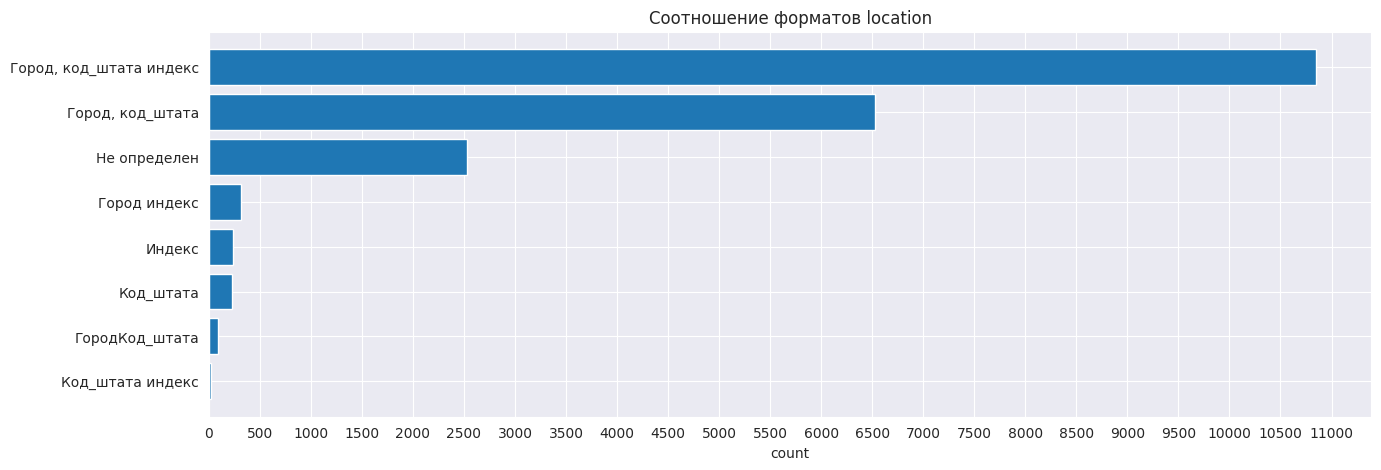

In [890]:
# patterns = [loc_state, loc_index, loc_city_state, loc_city_state_2, loc_city_state_index, loc_city_index, loc_state_index]
patterns = {
    "Код_штата": len(loc_state),
    "Индекс": len(loc_index),
    "Город, код_штата": len(loc_city_state),
    "ГородКод_штата": len(loc_city_state_2),
    "Город, код_штата индекс": len(loc_city_state_index),
    "Город индекс": len(loc_city_index),
    "Код_штата индекс": len(loc_state_index)
}
patterns["Не определен"] = len(df) - sum(patterns.values())
patterns_sorted = {
    i: patterns[i] for i in sorted(patterns, key=lambda x: patterns[x], reverse=False)
}
plt.figure(figsize=(15, 5))
plt.barh(patterns_sorted.keys(), patterns_sorted.values())
plt.xticks(range(0, max(list(patterns.values())) + 500, 500))
plt.xlabel("count")
plt.title('Соотношение форматов location')
plt.show()

In [891]:
for key, value in patterns_sorted.items():
  print(f"Формат {key}, количество записей - {value}")
print()
print(f"Формат определен у {round((sum(patterns.values()) - patterns['Не определен']) / len(df), 2)}% записей")

Формат Код_штата индекс, количество записей - 20
Формат ГородКод_штата, количество записей - 86
Формат Код_штата, количество записей - 230
Формат Индекс, количество записей - 239
Формат Город индекс, количество записей - 314
Формат Не определен, количество записей - 2530
Формат Город, код_штата, количество записей - 6525
Формат Город, код_штата индекс, количество записей - 10848

Формат определен у 0.88% записей


Как видно из диаграммы, подавляющее большинство записей, у которых получилось определить формат, относятся к форматам ```Город, код_штата индекс``` и ```Город, код_штата``` (причем записей первого формата больше половины от всех записей в датасете). Остальные форматы по отдельности не имеют большого веса и в сумме составляют 4% от количество строк, однако, раз из них можно вычленить полезные данные, то надо это сделать, равно как и попытаться извлечь хоть что-то из оставшихся "сложных" строк в ```location```

In [892]:
df[df["location"].str.match(r"^.*Address \S+[^,], [A-Z]{2} \d{5}$")]["location"]

,location
371,Contact name SHAKER ADVERTISING AGENCY noname ...
392,"Contact name Careers, AXA Address Charlotte, N..."
1411,"Address Monroe, LA 71201"
1477,"Address Houston, TX 77001"
1479,"Address Akron, OH 44301"
1482,"Address Charlotte, NC 28201"
1557,Contact name Pearl Martin Phone 516-798-3993 A...
1560,"Address FISHERS, IN 46037"
1564,"Contact name Careers, Legrand Address Anaheim,..."
1567,Contact name Vasim Phone 6093368111 Address Ha...


#### Задание 1.2

В большей части строк удалось извлечь данные из ячейки столбца `location`, но остались и такие, где это не получилось. Вынесите в отдельный датасет записи, в которых не удалось определить формат записи информации о местоположении.

Над оставшимися строками проведите следующие преобразования:
1. Данные о местоположении разделите на 3 столбца: город, код штата, почтовый индекс.
2. Так как значения в столбце `почтовый индекс` являются пятизначными числами, преобразуйте их в целочисленный формат.

NB от студента: индекс может начинаться с "0", поэтому приводить к целому числа - не лучшая затея

In [893]:
locations_ix = pd.concat([loc_state, loc_index, loc_city_state, loc_city_state_2, loc_city_state_index, loc_city_index, loc_state_index]).index
formatted_location = df.iloc[locations_ix]
formatted_location["state"] = formatted_location["location"].str.extract(r"([A-Z]{2})")
formatted_location["county_fips"] = formatted_location["location"].str.extract(r"(\d{5})")
formatted_location["city"] = formatted_location["location"].str.findall(r"([A-Z][a-z]+(?:\s[A-Z][a-z]+)*)").apply(lambda x: x[0] if x else np.nan)
formatted_location.sample(5)

,index,job_description,job_title,job_type,location,organization,page_url,salary,sector,state,county_fips,city
8540,9203,Print Production SpecialistFast growing e-comm...,Print Production Specialist Job in Sterling He...,Full Time,"Sterling Heights, MI 48310",Printing and Publishing,http://jobview.monster.com/Print-Production-Sp...,13.00 - 15.00 $ /hourbonuses,Student (Undergraduate/Graduate),MI,48310,Sterling Heights
2635,2832,The primary purpose of your job position is to...,LVN/RN - Generous Sign On Bonus Job in San Ant...,Full Time,"San Antonio, TX 78218",Healthcare Services,http://jobview.local-jobs.monster.com/LVN-RN-G...,NaN,NaN,TX,78218,San Antonio
20241,21427,Quintiles (NYSE: Q) is the world’s largest pro...,District Manager - Diabetes/Cardiovascular - I...,Full Time Employee,"Chicago, IL 60601",Biotechnology/Pharmaceuticals,http://jobview.monster.com/District-Manager-Di...,NaN,Sales/Retail/Business Development,IL,60601,Chicago
17941,19067,Job DescriptionI believe that the care we give...,Executive Director - Hospice Operations Job in...,NaN,"Phenix City, AL",Healthcare Services,http://jobview.monster.com/Executive-Director-...,NaN,NaN,AL,NaN,Phenix City
4002,4318,Job Description Job #: 695022Description: S...,OMNI - Picking Technician Job in West Chester,Full Time Employee,"West Chester, OH",Computer/IT Services,http://jobview.monster.com/omni-picking-techni...,NaN,Experienced (Non-Manager),OH,NaN,West Chester


Рассмотрите отложенную часть выборки (ту, где не удалось данные из столбца `location` разделить на три поля) и сделайте выводы о возможности извлечь из данных город, код штата и почтовый индекс. Извлеките все, что возможно. Что невозможно – оставьте пустым.

In [894]:
unformatted_loc = df.drop(formatted_location.index)

Из вывода ранее понятно, что строки без определенного формата также содержат информацию о локации. Чтобы ее получить, подключим [датасет](https://simplemaps.com/data/us-cities) с городами США и будем следовать следующему алгоритму.

Найдем в тексте ```location``` последнее пятизначное число, вероятнее всего, оно будет являться FIPS-кодом. Проверим, существует ли реально такой FIPS. Если да, то с помощью него можно однозначно получить код штата. Затем получим все упомянутые в тексте города и возьмем наиболее часто встречающийся среди тех, которые относятся к данному FIPS.

Если FIPS не найден, то получим все упоминания кодом штатов и городов из текста и пройдемся по их парам. Если такая пара действительно существует, получим для нее FIPS.

In [895]:
a = unformatted_loc["location"].str.findall(r'(?<!\d)\b\d{5}\b').apply(lambda x: x[-1] if x else np.nan)
a = a.rename("loc")
b = pd.concat([a, unformatted_loc["location"]], axis=1)
b[~b["loc"].isna()].iloc[286]["location"]

"35T Military Intelligence Systems Maintainer/Integrator Job ID: 774320 Job Views: 10 Location: SAN DIEGO, California, United States ZIP Code: 92111 Job Category: Signal and Military Intelligence Posted: 09.30.2016 Job DescriptionAs an Army National Guard Military Intelligence (MI) Systems Maintainer/Integrator, you play a vital role in the collection and interpretation of military intelligence information gathering so that our military experts can better plan our Nation's defense.The MI Systems Maintainer/Integrator maintains and integrates intelligence gathering systems, computers, and networks used by MI Soldiers. Specific duties as an MI Systems Maintainer/Integrator may include: maintaining, testing, and repairing communications equipment; maintaining and integrating MI computers and networks; assessing and extracting data from fixed, portable, and wireless storage/communication devices; and performing operational checks on MI aerial platforms, sensors, and systems.By joining the 

In [896]:
unformatted_loc.iloc[2]["location"]

'Sr. Process Engineer, Manufacturing'

In [897]:
uscities = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/files/uscities.csv")
uscities["county_fips"] = uscities["county_fips"].astype(str).str.rjust(5, "0")
uscities["city"] = uscities["city"].str.lower()
states_ids = set(uscities["state_id"])
cities_names = set(uscities["city"])
fips = set(uscities["county_fips"])
uscities.sample(5)

,city,city_ascii,state_id,state_name,county_fips,county_name,lat,lng,population,density,source,military,incorporated,timezone,ranking,zips,id
20251,lewis,Lewis,IA,Iowa,19029,Cass,41.3064,-95.0842,465,355.2,shape,False,True,America/Chicago,3,51544,1840008236
20109,the silos,The Silos,MT,Montana,30007,Broadwater,46.3985,-111.5865,474,35.7,shape,False,True,America/Denver,4,59644,1840039745
12311,galena,Galena,IN,Indiana,18043,Floyd,38.3513,-85.9372,1618,233.9,shape,False,False,America/Kentucky/Louisville,3,47124 47119,1840006265
16862,rich square,Rich Square,NC,North Carolina,37131,Northampton,36.2739,-77.2839,780,97.6,shape,False,True,America/New_York,3,27869,1840017701
20670,martelle,Martelle,IA,Iowa,19105,Jones,42.0204,-91.3578,432,231.3,shape,False,True,America/Chicago,3,52305,1840008106


In [898]:
def find_location_info(text):
  county_fips = re.findall(r'(?<!\d)\b\d{5}\b', text)
  county_fips = [i for i in county_fips if i in fips]
  county_fips = county_fips[-1] if county_fips else None

  if county_fips is not None:  # есть FIPS
    state_id = uscities[uscities["county_fips"] == county_fips].iloc[0]["state_id"]
  else:  # найдем все коды штатов в тексте
    state_id = re.findall(r'(?<!\w)\b[A-Z]{2}\b', text)
    state_id = [i for i in states_id if i in states_ids]


  pattern = r'\b(' + '|'.join(map(re.escape, cities_names)) + r')\b'
  cities = set(re.findall(pattern, text.lower()))

  # cities = [i for i in cities_names if i in text.lower()] # найдем все города
  if county_fips is not None:  # если есть FIPS, найдем наиболее часто встречающийся город, который имеет этот FIPS
    cities = [i for i in cities if i in uscities[uscities["county_fips"] == county_fips]["city"]]
    if cities:
      return county_fips, state_id, max(set(cities), key=cities.count).title()
    return county_fips, state_id, np.nan

  for city in cities:  # иначе вернем пару город, код штата, которые действителньо существуют
    for state in state_id:
      rows = uscities[(uscities["city"].str.lower() == city) & (uscities["state_id"] == state)]
      if len(rows) != 0:
        return rows.iloc[0]["county_fips"], state, city.title()
  return np.nan, np.nan, np.nan

In [899]:
new_locs = []
for ix, row in unformatted_loc.iterrows():
  new_locs.append(find_location_info(row["location"]))
  if len(new_locs) % 100 == 0:
    print(len(new_locs))
unformatted_loc[["county_fips", "state", "city"]] = np.array(new_locs)

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500


In [900]:
unformatted_loc = unformatted_loc.replace('nan', np.nan)

In [901]:
unformatted_loc[~unformatted_loc["county_fips"].isna()].sample(10)

,index,job_description,job_title,job_type,location,organization,page_url,salary,sector,county_fips,state,city
7149,7738,Job DescriptionKindred at Home is currently se...,Caregiver - Home Health Aide Job in Las Vegas,"Part Time, Employee",Job DescriptionKindred at Home is currently se...,Healthcare Services,http://jobview.monster.com/Caregiver-Home-Heal...,NaN,Medical/Health,06037,CA,Industry
5722,6252,Report this job About the Job CUSTOM FACILITIE...,Talent Fusion™ by Monster Job Application for ...,Full Time,CUSTOM FACILITIES JOB TITLE Commercial Project...,All,http://jobview.monster.com/commercial-construc...,NaN,NaN,06037,CA,Industry
20322,21515,"Job Description : Position: Manager, Service a...",Manager,"Full Time , Employee","Job Description : Position: Manager, Service a...",Retail,http://jobview.monster.com/Manager-Service-Tra...,NaN,Experienced (Non-Manager),06097,CA,Kenwood
2445,2617,Registered Nurse (licensed New Graduates welco...,Registered Nurse (licensed New Graduates welco...,"Full Time, Employee",Registered Nurse (licensed New Graduates welco...,Healthcare Services,http://jobview.monster.com/registered-nurse-li...,NaN,Medical/Health,06037,CA,Pasadena
2297,2463,Report this job About the Job We are seeking d...,Apple Ridge Academy Job Application for Seekin...,"Full Time, Employee",Contact name Tammy Imme Phone 262-783-5437 Add...,Education; Other/Not Classified,http://jobview.monster.com/seeking-infant-todd...,NaN,NaN,21005,KY,NaN
12381,13158,"When you choose Toll Brothers, you enjoy all t...",PROJECT MANAGEMENT TRAINEE Job in San Ramon,"Full Time, Employee","When you choose Toll Brothers, you enjoy all t...",AllReal Estate/Property ManagementConstruction...,http://jobview.monster.com/PROJECT-MANAGEMENT-...,NaN,Project/Program Management,06037,CA,Industry
13668,14472,Job Functions :Leads the CDM study team and ma...,Study Data Manager Job in South San Francisco,"Full Time, Temporary/Contract/Project","South San Francisco, CA",NaN,http://jobview.monster.com/study-data-manager-...,NaN,NaN,06081,CA,South San Francisco
11536,12276,Report this job About the Job Job Description ...,Auto Club Group Job Application for Valet | Mo...,"Full Time, Employee","Contact name Talent Acquisition, ACG Address N...",Automotive Sales and Repair Services,http://jobview.monster.com/valet-job-north-riv...,NaN,NaN,06065,CA,Riverside
18921,20061,Logistics Structure and Materials Flow Plannin...,Monster,NaN,Logistics Structure and Materials Flow Plannin...,NaN,http://jobview.monster.com/logistics-structure...,NaN,NaN,06063,CA,Greenville
13424,14216,"Finance Director - Travel Industry, ERP Implem...",Finance Director - Travel Industry,NaN,"Finance Director - Travel Industry, ERP Implem...",NaN,http://jobview.monster.com/finance-director-tr...,NaN,NaN,06037,CA,Industry


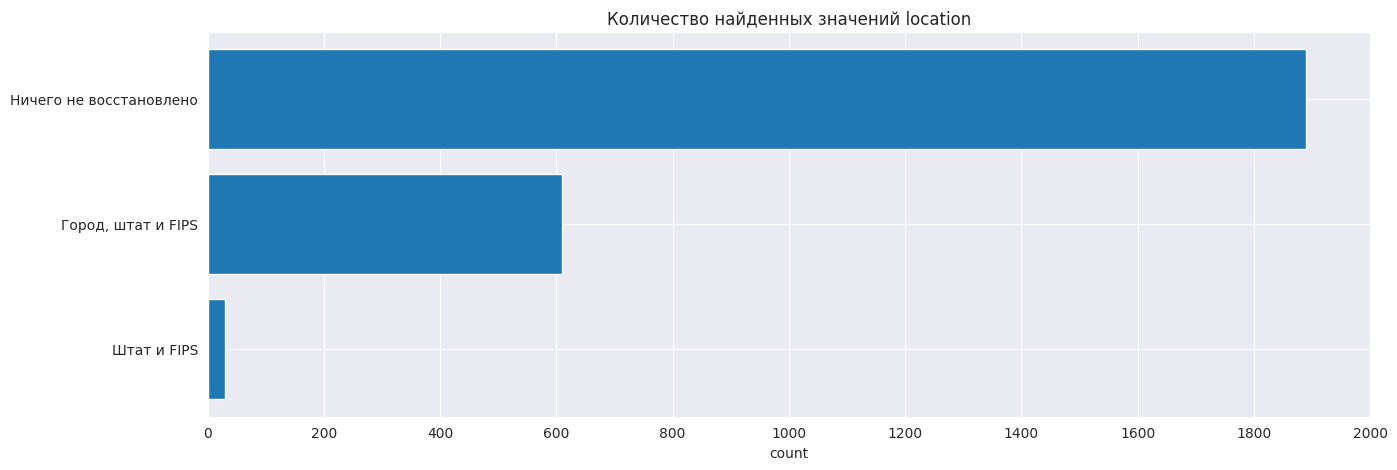

In [902]:
restored_count = unformatted_loc[~unformatted_loc.iloc[:, -3:].isna().all(axis=1)]
all_restored = restored_count[~restored_count["city"].isna()]
fips_state_restored = restored_count[(restored_count["city"].isna()) & (~restored_count["state"].isna())]
restored_dict = {
    "Город, штат и FIPS": len(all_restored),
    "Штат и FIPS": len(fips_state_restored),
    "Ничего не восстановлено": len(unformatted_loc) - len(restored_count)
}
restored_dict_sort = {
    i: restored_dict[i] for i in sorted(restored_dict, key=lambda x: restored_dict[x], reverse=False)
}
plt.figure(figsize=(15, 5))
plt.barh(restored_dict_sort.keys(), restored_dict_sort.values())
plt.xticks(range(0, max(list(restored_dict_sort.values())) + 200, 200))
plt.xlabel("count")
plt.title('Количество найденных значений location')
plt.show()

In [903]:
restored_dict_sort

{'Штат и FIPS': 30, 'Город, штат и FIPS': 610, 'Ничего не восстановлено': 1890}

С помощью подключения стороннего датасета с городами США получилось вычленить информацию о локации для 640 строк (3% всего датасета), причем 610 из них были восстановлены полностью (город, штат и FIPS)

In [904]:
df = pd.concat([formatted_location, unformatted_loc]).drop(columns=["index", "location"]).sort_index()

In [905]:
df

,job_description,job_title,job_type,organization,page_url,salary,sector,state,county_fips,city
0,TeamSoft is seeing an IT Support Specialist to...,IT Support Technician Job in Madison,Full Time Employee,NaN,http://jobview.monster.com/it-support-technici...,NaN,IT/Software Development,WI,53702,Madison
1,The Wisconsin State Journal is seeking a flexi...,Business Reporter/Editor Job in Madison,Full Time,Printing and Publishing,http://jobview.monster.com/business-reporter-e...,NaN,NaN,WI,53708,Madison
2,Report this job About the Job DePuy Synthes Co...,Johnson & Johnson Family of Companies Job Appl...,"Full Time, Employee",Personal and Household Services,http://jobview.monster.com/senior-training-lea...,NaN,NaN,CA,06037,Industry
3,Why Join Altec? If you’re considering a career...,Engineer - Quality Job in Dixon,Full Time,Altec Industries,http://jobview.monster.com/engineer-quality-jo...,NaN,Experienced (Non-Manager),CA,NaN,Dixon
4,Position ID# 76162 # Positions 1 State CT C...,Shift Supervisor - Part-Time Job in Camphill,Full Time Employee,Retail,http://jobview.monster.com/shift-supervisor-pa...,NaN,Project/Program Management,PA,NaN,Camphill
...,...,...,...,...,...,...,...,...,...,...
20787,This is a major premier Cincinnati based finan...,Assistant Vice President - Controller Job in C...,Full Time,NaN,http://jobview.monster.com/Assistant-Vice-Pres...,"120,000.00 - 160,000.00 $ /yearbonus",NaN,OH,NaN,Cincinnati
20788,Luxury homebuilder in Cincinnati seeking multi...,Accountant Job in Cincinnati,Full Time,Construction - Residential & Commercial/Office,http://jobview.monster.com/Accountant-Job-Cinc...,"45,000.00 - 60,000.00 $ /year",Manager (Manager/Supervisor of Staff),OH,45236,Cincinnati
20789,RE: Adobe AEM- Client - Loca...,AEM/CQ developer Job in Chicago,Full Time,NaN,http://jobview.monster.com/AEM-CQ5-developer-J...,NaN,NaN,IL,60602,Chicago
20790,Jernberg Industries was established in 1937 an...,Electrician - Experienced Forging Electrician ...,Full Time Employee,"Jernberg Industries, Inc.",http://jobview.monster.com/Electrician-Experie...,25.00 - 28.00 $ /hour,Installation/Maintenance/Repair,IL,60609,Chicago


### Задание 2

В задании 2 необходимо провести обработку столбца `salary`.

#### Задание 2.1

В столбце `salary`, как и в `location`, данные не стандатизированы. В нем в основном можно встретить записи в следующих форматах:

* 10.00 - 20.00 &dollar; &sol;hour
* 10,000.00 - 20,000.00 &dollar; &sol;year
* &dollar;10.00 &sol;hour
* &dollar;10,000.00+ &sol;year
* Up to &dollar;20,000.00

Основные проблемы, которые стоит учесть при обработке форматов:
- В каждом из форматов может быть или не быть знака доллара.
- Может отсутствовать информация о периоде, за который указывается зарплата (`/hour` или `/year` в примерах).
- Зарплата может быть указана за месяц (`/month`) и за неделю (`/week`).
- В начале, конце и середине некоторых строк есть лишние пробелы, которые не стоит учитывать.

**Задание:**
1. Определите весь перечень встречающихся форматов и напишите одно или несколько регулярных выражений для их поиска.
2. Покажите на столбчатой диаграмме количество записей, содержащих каждый из форматов. Сделайте выводы.

In [906]:
sorted_salary = df.iloc[df["salary"].str.len().sort_values().index, :]["salary"]
prev = 0
for i in sorted_salary:
  # if len(i) != prev:
  #   print(i)
  #   prev = len(i)
  print(i)
  if len(i) > 20:
    break

 
 
 
DOE
BOE
BOE
mid
BOE
DOE
DOE
DOE
DOE
BOE
DOE
DOE
DOE
DOE
BOE
PTO
BOE
BOE
DOE
DOE
TBD
DOE
8.00
8.00
12.50
Bonus
12.50
13.00
Hourly
Hourly
Salary
Hourly
Salary
Bonuses
bonuses
bonuses
Base plus
Negotiable
Commission
Compeitive
Negotiable
Negotiable
Bonus plan
negotiable
Salary DOE
Negotiable
gratuities
Commission
Commission
Competitive
Competitive
Hourly Wage
Competitive
Up to $9.94
Competitive
Hourly Wage
Hourly Wage
Competitive
Hourly Wage
Competitive
Competitive
Hourly Wage
Competitive
Competitive
Up to $9.50
Competative
Competitive
Competitive
Up to $40.00
Up to $20.00
Up to $58.00
22.00+ /hour
Up to $20.00
13.00+ /hour
$9.47+ /hour
$9.50+ /hour
Up to $16.00
$12.50-13.00
14.00+ /hour
DOE - Salary
Up to $18.00
$8.74+ /hour
Up to $15.00
Up to $12.00
Base + Bonus
16.00+ /hour
16.89+ /hour
Up to $20.00
Up to $18.00
$Competitive
Up to $25.00
Up to $14.00
Up to $55.00
Up to $16.00
Up to $13.00
Up to $14.00
Up to $15.00
Up to $10.00
Up to $15.00
Up to $13.00
Up to $15.00
Up to $10.00
2

Можно выделить следующие форматы зарплаты:

45,000.00 - 100,000.00 $ /year ```\d+(?:,\d{3})*(?:\.\d{2})? - \d+(?:,\d{3})*(?:\.\d{2})?```

$15.00+ /hour ```\d+(?:,\d{3})*(?:\.\d{2})?\+```

Up to $40.00 ```Up to \S+\d+(?:,\d{3})*(?:\.\d{2})?```

12.50 ```^\d+(?:,\d{3})*(?:\.\d{2})?$```



In [907]:
salary = df[(~df["salary"].isna()) & (df["salary"].str.contains("\d+"))]["salary"]  # будем смотреть только те строки где есть числа то есть там указана какая-то ЗП
# замеим все ЗП типа 75k на 75,000.00, кроме 401k; это не зп, а пенсионный план
salary = salary.apply(lambda x: re.sub(r"\b(?!401)(\d+)[kK]", r'\g<1>,000.00', x))
ptrn = r"\d+(?:,\d{3})*(?:\.\d{2})?"

In [908]:
from_to_sal = salary[salary.str.match(rf".*{ptrn} - {ptrn}.*")]
from_to_sal.sample(5)

,salary
7894,0.00 - 18.00 $ /hour
17895,12.00 - 13.00 $ /hour
19480,0.00 - 14.00 $ /hour
13305,"60,000.00 - 90,000.00 $ /yearbonus based on pr..."
18540,"35,000.00 - 40,000.00 $ /yearBonuses"


In [909]:
from_sal = salary[salary.str.match(rf".*{ptrn}\+\s/")]
from_sal.sample(5)

,salary
20690,"$32,000.00+ /year"
16346,16.00+ /hour
16479,"110,000.00+ /year"
12789,"85,000.00+ /year"
6845,$10.50+ /hour


In [910]:
up_to_sal = salary[salary.str.match(rf"Up to .*{ptrn}")]
up_to_sal.sample(5)

,salary
7126,Up to $9.94
6994,Up to $15.00
2875,Up to $31000.00
40,Up to $32000.00
7049,Up to $10.00


In [911]:
just_num_sal = salary[salary.str.match(rf"^{ptrn}$")]
just_num_sal.sample(5)

,salary
17084,8.00
16555,12.50
16444,8.00
16116,13.00
17195,12.50


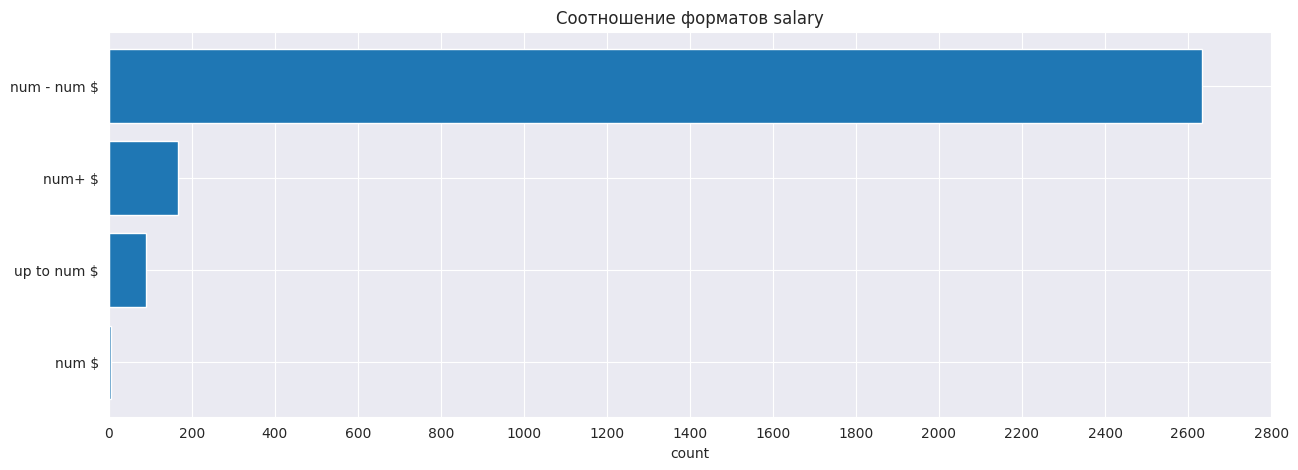

In [912]:
sals = {
    "num - num $": len(from_to_sal),
    "num+ $": len(from_sal),
    "up to num $": len(up_to_sal),
    "num $": len(just_num_sal)
}
sals_sort = {
    i: sals[i] for i in sorted(sals, key=lambda x: sals[x])
}
plt.figure(figsize=(15, 5))
plt.barh(sals_sort.keys(), sals_sort.values())
plt.xticks(range(0, max(list(sals_sort.values())) + 200, 200))
plt.xlabel("count")
plt.title('Соотношение форматов salary')
plt.show()

In [913]:
sals, len(salary)

({'num - num $': 2633, 'num+ $': 166, 'up to num $': 91, 'num $': 5}, 2939)

Подавляющее большинство значений зарплаты имеет формат ```num - num $``` (без учета периода). Всего формат определен для 2886 строк, что составляет 98% от всех записей, где ```salary``` - не NaN

#### Задание 2.2

1. Разделите столбец `salary` зарплаты три: `минимальная граница зарплаты`, `максимальная граница зарплаты`, `период`. Если значение суммы указано только одно, считайте, что это минимальная зарплата. Значение суммы в обоих столбцах преобразуйте в формат `float`.
2. Покажите на столбчатой диаграмме с группировкой среднюю и медианную минимальную зарплату в каждом периоде. Сделайте выводы.

In [914]:
period = salary.str.lower().str.extract(r"/(year|hour|month|week)")

In [915]:
from_to_sal = from_to_sal.to_frame()
from_to_sal[["min_salary", "max_salary"]] = from_to_sal["salary"].str.findall(ptrn).apply(lambda x: [x[0], x[1]]).tolist()
from_to_sal.sample(5)

,salary,min_salary,max_salary
17097,12.90 - 13.76 $ /hour,12.90,13.76
20319,"70,000.00 - 70,000.00 $ /yearBonus potential","70,000.00","70,000.00"
15538,9.00 - 11.00 $ /hour,9.00,11.00
6980,"125,000.00 - 175,000.00 $ /year","125,000.00","175,000.00"
17936,13.00 - 14.00 $ /hour,13.00,14.00


In [916]:
from_sal = from_sal.to_frame()
from_sal[["min_salary", "max_salary"]] = from_sal["salary"].str.findall(ptrn).apply(lambda x: [x[0], np.nan]).tolist()
from_sal.sample(5)

,salary,min_salary,max_salary
7352,"$67,500.00+ /year","67,500.00",NaN
18011,"$50,000.00+ /year","50,000.00",NaN
1132,22.00+ /hour,22.00,NaN
590,"45,000.00+ /year","45,000.00",NaN
7439,"$51,446.00+ /year","51,446.00",NaN


In [917]:
up_to_sal = up_to_sal.to_frame()
up_to_sal[["min_salary", "max_salary"]] = up_to_sal["salary"].str.findall(ptrn).apply(lambda x: [x[0], np.nan]).tolist()
up_to_sal.sample(5)

,salary,min_salary,max_salary
11392,Up to $15.00,15.00,NaN
4883,Up to $55000.00,55000.00,NaN
5182,Up to $65000.00,65000.00,NaN
3332,Up to $14.00,14.00,NaN
5037,Up to $40000.00,40000.00,NaN


In [918]:
just_num_sal = just_num_sal.to_frame()
just_num_sal[["min_salary", "max_salary"]] = just_num_sal["salary"].str.findall(ptrn).apply(lambda x: [x[0], np.nan]).tolist()
just_num_sal.sample(5)

,salary,min_salary,max_salary
17195,12.50,12.50,NaN
17084,8.00,8.00,NaN
16116,13.00,13.00,NaN
16555,12.50,12.50,NaN
16444,8.00,8.00,NaN


In [919]:
pd.concat([pd.concat([from_to_sal, from_sal, up_to_sal, just_num_sal]).drop(columns=["salary"]), period], axis=1)

,min_salary,max_salary,0
13,9.00,13.00,hour
14,"80,000.00","95,000.00",year
18,"60,000.00","72,000.00",year
27,"70,000.00","100,000.00",year
28,62.00,81.00,hour
...,...,...,...
18455,NaN,NaN,NaN
20149,NaN,NaN,NaN
20242,NaN,NaN,NaN
20401,NaN,NaN,NaN


In [920]:
salary_info = pd.concat([from_to_sal, from_sal, up_to_sal, just_num_sal]).drop(columns=["salary"])
salary_info["period"] = period

salary_info["min_salary"] = salary_info["min_salary"].str.replace(",", "").astype(float)
salary_info["max_salary"] = salary_info["max_salary"].str.replace(",", "").astype(float)

In [921]:
salary_info

,min_salary,max_salary,period
13,9.0,13.0,hour
14,80000.0,95000.0,year
18,60000.0,72000.0,year
27,70000.0,100000.0,year
28,62.0,81.0,hour
...,...,...,...
16116,13.0,NaN,NaN
16444,8.0,NaN,NaN
16555,12.5,NaN,NaN
17084,8.0,NaN,NaN


In [922]:
salary_info[salary_info["min_salary"].isna()]

,min_salary,max_salary,period


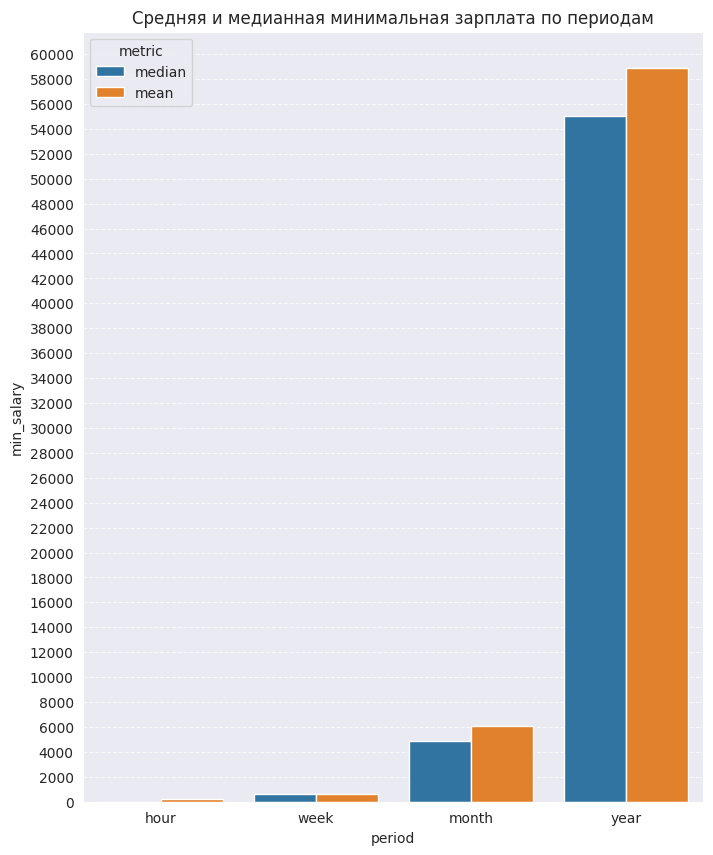

In [923]:
stats = salary_info.groupby("period")["min_salary"].agg(["mean", "median"]).reset_index()
stats_long = stats.melt(id_vars="period", var_name="metric", value_name="min_salary")
stats_long = stats_long.sort_values("min_salary")

plt.figure(figsize=(8, 10))
sns.barplot(data=stats_long, x="period", y="min_salary", hue="metric")

plt.title("Средняя и медианная минимальная зарплата по периодам")
plt.ylabel("min_salary")
plt.xlabel("period")
plt.legend(title="metric")
plt.yticks(range(0, int(max(stats_long["min_salary"])) + 2000, 2000))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [924]:
stats_long

,period,metric,min_salary
4,hour,median,15.000000
0,hour,mean,196.553740
2,week,mean,593.666667
6,week,median,600.000000
5,month,median,4905.220000
1,month,mean,6048.408824
7,year,median,55000.000000
3,year,mean,58855.308954


In [925]:
salary_info[salary_info["period"] == "hour"]["min_salary"].max(), salary_info[salary_info["period"] == "week"]["min_salary"].max(), salary_info[salary_info["period"] == "month"]["min_salary"].max(), salary_info[salary_info["period"] == "year"]["min_salary"].max()

(100000.0, 1100.0, 17688.94, 1000000.0)

In [926]:
salary_info[salary_info["period"] == "hour"]["min_salary"].sort_values().tail(10)

,min_salary
1210,75.0
20699,75.0
6361,75.0
12747,80.0
2811,84.0
1096,100.0
18761,100.0
11665,32000.0
9620,60000.0
6333,100000.0


Значения среднего и медианы минимальной зарплаты в каждом периоде позволяют говорить о возможности сравнивать ЗП без указанного периода со средним по периоду и делать выводы, к какому периоду, вероятнее всего, относится ЗП, поскольку значения среднего и медианы значительно отличаюстя в зависимости от периода.

Однако у периода ```hour``` есть явные выбросы (32000, 60000 и 100000), и это надо учитывать, ведь они влияют на среднее значение и могут привести к неправильному соотнесению ЗП и периода (можно посчитать, что ЗП за неделю должна быть за час из-за выборосов)

#### Задание 2.3

Как было отмечено в задании 2.1, период, за который указывается зарплата, может отсутствовать. Восполните этот пробел в данных следующим образом:

1. Определите диапазон изменения (разброс) значений денежной суммы за каждый из встречающихся в данных периодов. Постройте гистограмму для каждого периода.
2. Определите, к среднему значению за какой период ближе всего сумма, у которой период не указан. Укажите для найденный период. В спорных случаях, где сумма одинаково близка к нескольким диапазонам, не выбирайте ничего.

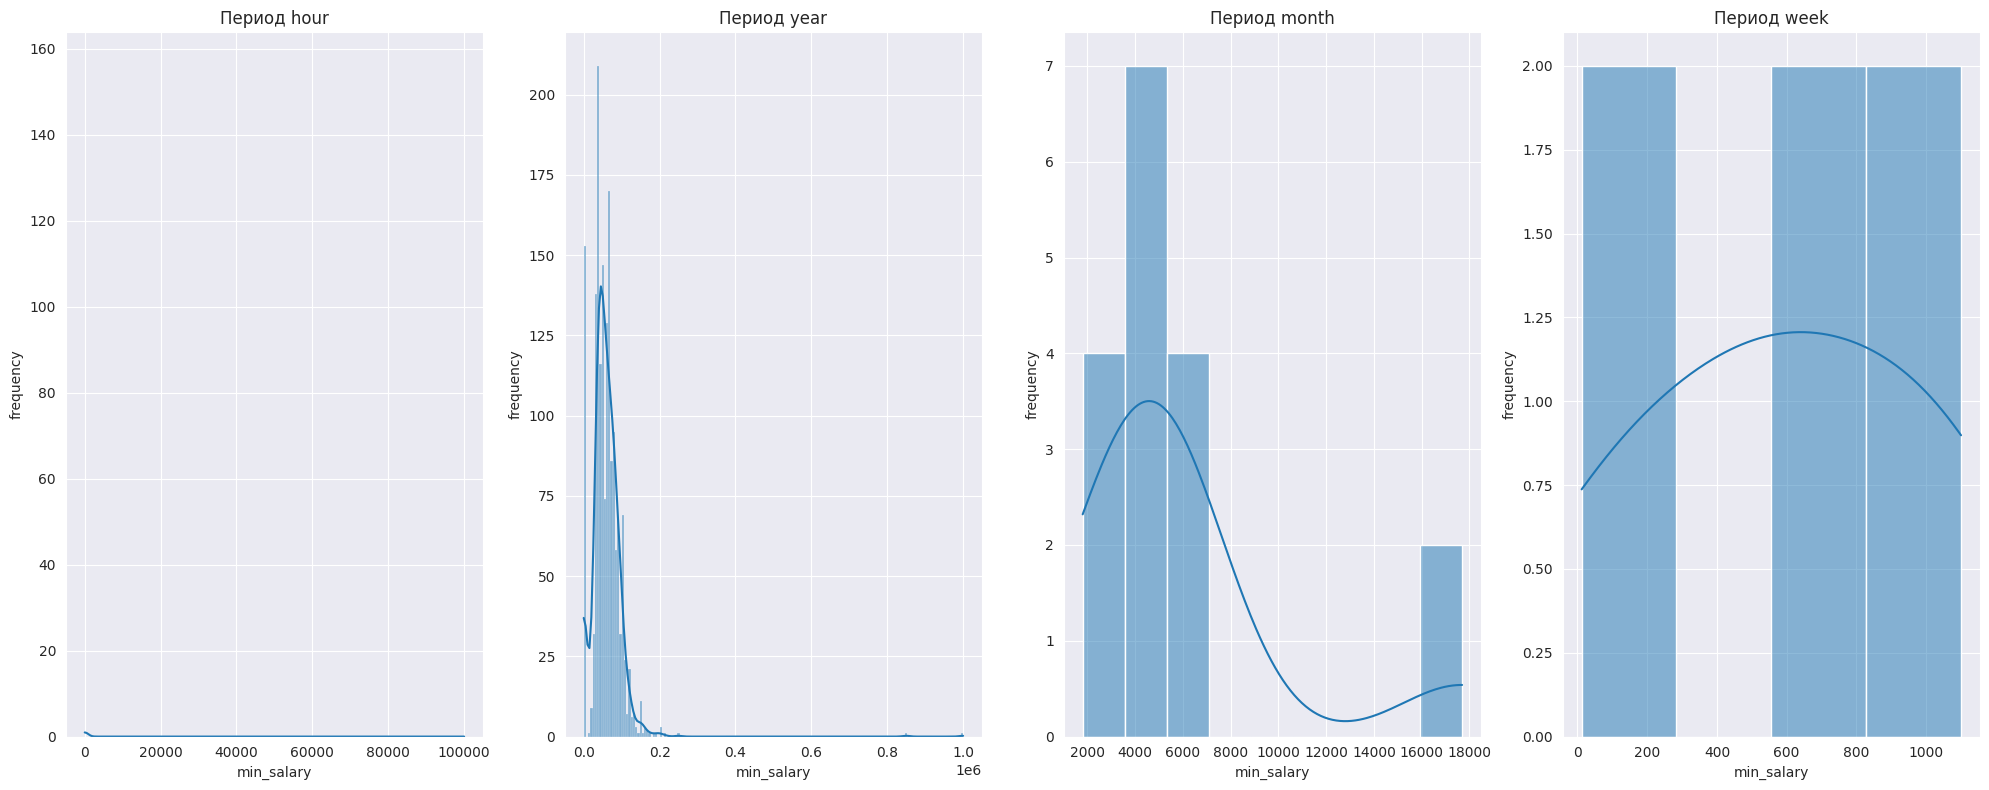

In [927]:
range_df = salary_info.groupby("period")["min_salary"].agg(["min", "max"])
range_df["range"] = range_df["max"] - range_df["min"]

periods = salary_info[~salary_info["period"].isna()]["period"].unique()
plt.figure(figsize=(20, 8))

for i, period in enumerate(periods, 1):
    plt.subplot(1, len(periods), i)
    sns.histplot(salary_info[salary_info["period"] == period]["min_salary"], kde=True)
    plt.title(f"Период {period}")
    plt.xlabel("min_salary")
    plt.ylabel("frequency")

plt.tight_layout()
plt.show()

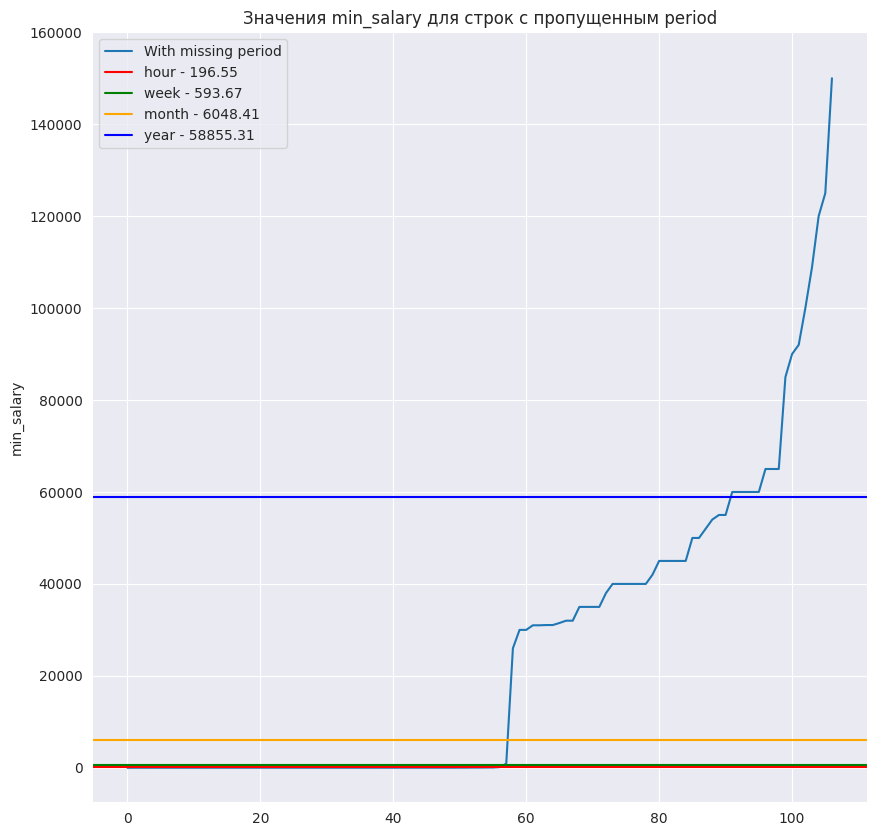

In [928]:

plt.figure(figsize=(10, 10))
plt.plot(sorted(salary_info[salary_info["period"].isna()]["min_salary"]), label="With missing period")
for c, i in zip(["red", "green", "orange", "blue"], ["hour",  "week", "month", "year"]):
  hline = stats_long[(stats_long["period"] == i) & (stats_long["metric"] == "mean")]["min_salary"].iloc[0]
  plt.axhline(hline, label=f"{i} - {round(hline, 2)}", c=c)
max_value = int(max(salary_info[salary_info["period"].isna()]["min_salary"]))
plt.yticks(range(0, int(max_value) + 20000, 20000))
plt.ylabel("min_salary")
plt.title("Значения min_salary для строк с пропущенным period")
plt.legend()
plt.show()


Для определения периода у значений с пропусками будем смотреть на относительную ошибку среднего/медианы как оценки и истинного значения. Период с наимньшей относительной ошибкой и выберем, однако введем некоторое пороговое значение, которое должно быть между двумя минимальными значениями относительной погрешности, чтобы считать, что эти погрешности не равны (например, погрешности 0.998 и 0.987 не одинаковые, но достаточно близкие, чтобы мы не могли однозначно сказать, к какому периоду относится зарплата)

In [929]:
def get_nearest_period(x, metric="mean", threshold=0.1):
  if not pd.isna(x["period"]):
    return x["period"]
  if x["min_salary"] != 0:
    diff = stats[metric].apply(lambda m: abs(m - x["min_salary"]) / x["min_salary"])
  else:
    diff = stats[metric].apply(lambda m: m / x["max_salary"])
  print(diff)
  diff_sort = diff.sort_values()
  if abs(diff_sort.iloc[0] - diff_sort.iloc[1]) < threshold:
    return np.nan
  return stats.iloc[diff.argmin(), 0]


In [930]:
salary_info["period"] = salary_info.apply(lambda x: get_nearest_period(x, threshold=0.3, metric="median"), axis=1)
salary_info[salary_info["period"].isna()]

0    0.999862
1    0.954951
2    0.994490
3    0.494889
Name: median, dtype: float64
0     0.015625
1     5.109604
2     0.625000
3    57.291667
Name: median, dtype: float64
0       0.456311
1     475.234951
2      57.252427
3    5338.805825
Name: median, dtype: float64
0       0.666667
1     544.024444
2      65.666667
3    6110.111111
Name: median, dtype: float64
0       0.363636
1     444.929091
2      53.545455
3    4999.000000
Name: median, dtype: float64
0       0.469148
1     479.432909
2      57.765916
3    5385.875612
Name: median, dtype: float64
0    0.999517
1    0.842042
2    0.980679
3    0.771108
Name: median, dtype: float64
0      0.900000
1     31.701467
2      3.000000
3    365.666667
Name: median, dtype: float64
0    0.999625
1    0.877370
2    0.985000
3    0.375000
Name: median, dtype: float64
0    0.999517
1    0.842042
2    0.980679
3    0.771108
Name: median, dtype: float64
0     0.983333
1     4.450244
2     0.333333
3    60.111111
Name: median, dtype: float64
0

,min_salary,max_salary,period
16072,31054.0,31054.0,NaN
17032,31054.0,31054.0,NaN
40,32000.0,NaN,NaN
2598,30000.0,NaN,NaN
2875,31000.0,NaN,NaN
4770,35000.0,NaN,NaN
4936,32000.0,NaN,NaN
7125,30000.0,NaN,NaN
7190,26000.0,NaN,NaN
7212,31000.0,NaN,NaN


In [931]:
df[["min_salary", "max_salary", "period"]] = np.nan
df.loc[salary_info.index, ["min_salary", "max_salary", "period"]] = salary_info.to_numpy()
df = df.drop(columns=["salary"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20792 entries, 0 to 20791
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_description  20792 non-null  object 
 1   job_title        20792 non-null  object 
 2   job_type         19273 non-null  object 
 3   organization     14196 non-null  object 
 4   page_url         20792 non-null  object 
 5   sector           15875 non-null  object 
 6   state            18349 non-null  object 
 7   county_fips      12061 non-null  object 
 8   city             18383 non-null  object 
 9   min_salary       2895 non-null   float64
 10  max_salary       2633 non-null   float64
 11  period           2881 non-null   object 
dtypes: float64(2), object(10)
memory usage: 2.6+ MB


### Задание 3

В задании 3 необходимо провести обработку столбца `job_type`. Выясните, какие форматы значений есть в столбце `job_type`. Сделайте выводы. При необходимости – стройте графики.

In [932]:
df["job_type"].value_counts(), df["job_type"].nunique()

(job_type
 Full Time                                        6413
 Full Time Employee                               6345
 Full Time, Employee                              3107
 Full Time Temporary/Contract/Project             1009
 Full Time, Temporary/Contract/Project             514
 Full Time , Employee                              381
 Part Time Employee                                319
 Part Time                                         318
 Temporary/Contract/Project                        185
 Part Time, Employee                               184
 Employee                                          146
 Full Time / Employee                              109
 Full Time , Temporary/Contract/Project             48
 Per Diem, Employee                                 29
 Part Time, Temporary/Contract/Project              24
 Per Diem                                           22
 Job Type Full Time Employee                        19
 Full Time                                          14


Видно, что уникальных значений в столбце ```job_type``` всего 39, и они имеют схожую структуру, поэтому их можно стандартизировать

Глобально формат занятости выглядит как ```<Время занятости> <Тип занятости>```, где время занятости может быть Full Time, Part Time и Per Diem (полный рабочий день, частичная занятость и посуточная), а тип занятости принимает значения Employee (сотрудник), Intern (стажер), Exempt (освобожденный работник) и Temporary/Contract/Project (временная занятость для какого-то проекта). Одно из значений может отличаться

Вы заметили, что многие значения фактически одинаковые, но немного по-разному отформатированы? Приведем их к единому формату.

In [933]:
job_time = df["job_type"].str.extract("(Full Time|Part Time|Per Diem)").iloc[:, 0]
job_empl_type =  df["job_type"].str.extract("(Employee|Intern|Temporary/Contract/Project|Exempt)").iloc[:, 0]

Столбец `job_type` состоит из двух частей: "полнота" занятости (`Full Time`, `Part Time`, `Per Diem`) и "тип" занятости (`Employee`, `Intern`). Кроме того, встречаются и неполные записи.

Задание:
1. Написать одно или несколько регулярных выражений для разделения столбца `job_type` на два: `полнота занятости`, `тип занятости`.
2. Если данные о полноте отсутствуют, внесите значение `Full Time`.
Если отсутствуют данные о типе – внесите `Employee`.
3. Постройте столбчатую диаграмму со стековой группировкой для полноты и типа занятости. Сделайте выводы.

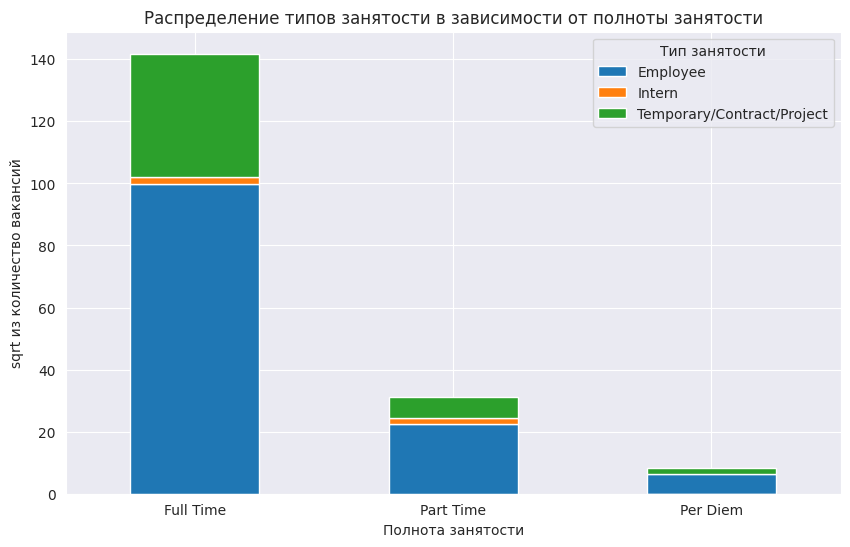

In [935]:
job_type_updated = pd.concat([job_time, job_empl_type], axis=1)
job_type_updated.columns = ["time_employment", "type_employment"]
pivot = job_type_updated.pivot_table(index="time_employment", columns="type_employment", aggfunc="size", fill_value=0)

np.sqrt(pivot).plot(kind="bar", stacked=True, figsize=(10, 6))

plt.title("Распределение типов занятости в зависимости от полноты занятости")
plt.xlabel("Полнота занятости")
plt.ylabel("sqrt из количество вакансий")
plt.legend(title="Тип занятости")
plt.xticks(rotation=0)
plt.show()

Итог подзадания: столбец ```job_type``` получилось стандартизировать и преобразовать в два независимых столбца. На диаграмме видно, что преобладающий вес имеет занятость Full Time, а преобладающий тип занятости - Employeee.

In [936]:
job_type_updated["time_employment"].fillna("Full Time", inplace=True)
job_type_updated["type_employment"].fillna("Employee", inplace=True)
df.loc[job_type_updated.index, ["time_employment", "type_employment"]] = job_type_updated
df = df.drop(columns=["job_type"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20792 entries, 0 to 20791
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_description  20792 non-null  object 
 1   job_title        20792 non-null  object 
 2   organization     14196 non-null  object 
 3   page_url         20792 non-null  object 
 4   sector           15875 non-null  object 
 5   state            18349 non-null  object 
 6   county_fips      12061 non-null  object 
 7   city             18383 non-null  object 
 8   min_salary       2895 non-null   float64
 9   max_salary       2633 non-null   float64
 10  period           2881 non-null   object 
 11  time_employment  20792 non-null  object 
 12  type_employment  20792 non-null  object 
dtypes: float64(2), object(11)
memory usage: 2.7+ MB


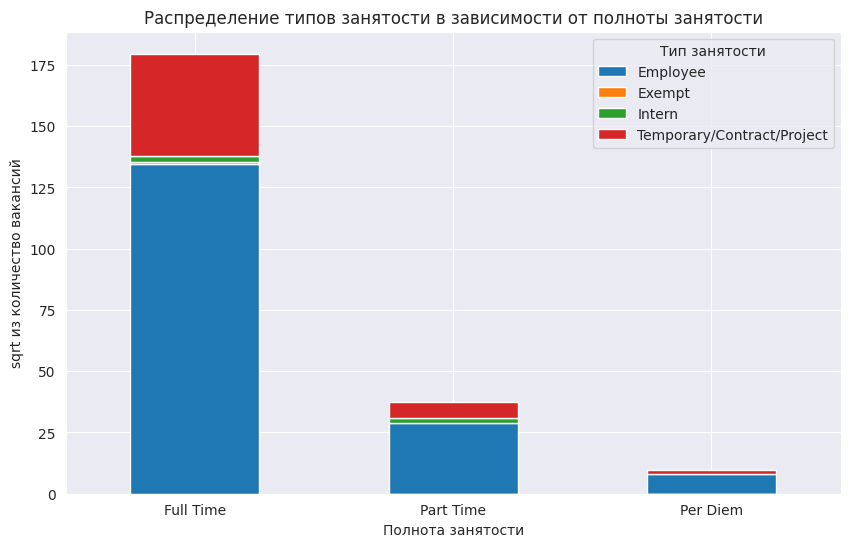

In [941]:
pivot = df[["time_employment", "type_employment"]].pivot_table(index="time_employment", columns="type_employment", aggfunc="size", fill_value=0)

np.sqrt(pivot).plot(kind="bar", stacked=True, figsize=(10, 6))

plt.title("Распределение типов занятости в зависимости от полноты занятости")
plt.xlabel("Полнота занятости")
plt.ylabel("sqrt из количество вакансий")
plt.legend(title="Тип занятости")
plt.xticks(rotation=0)
plt.show()

In [939]:
df.sample(15)

,job_description,job_title,organization,page_url,sector,state,county_fips,city,min_salary,max_salary,period,time_employment,type_employment
20048,Sentara. Your Community Not-For-Profit Health ...,PHYSICIAN RECRUITER SPECIALIST - Sentara Medic...,Healthcare Services,http://jobview.monster.com/PHYSICIAN-RECRUITER...,Experienced (Non-Manager),VA,23501,Norfolk,NaN,NaN,NaN,Full Time,Employee
20145,"Hi,We have urgent openings for one of our cust...",Data Integration Specialist Job in Cincinnati,Internet Services,http://jobview.monster.com/Data-Integration-Sp...,Experienced (Non-Manager),OH,45201,Cincinnati,NaN,NaN,NaN,Full Time,Employee
11089,« back Learn More Scrum Master/Agile Coach Job...,Scrum Master/Agile Coach Job in Boston,Computer/IT Services,http://jobview.monster.com/scrum-master-agile-...,Experienced (Non-Manager),CA,06037,Industry,NaN,NaN,NaN,Full Time,Employee
12780,Assoc Director Quality-POS_00470305-1Descripti...,Assoc Director Quality Job in Westborough,Biotechnology/Pharmaceuticals,http://jobview.monster.com/Assoc-Director-Qual...,Quality Assurance/Safety,MA,NaN,Westborough,NaN,NaN,NaN,Full Time,Employee
5088,"Immigration law firm Chavez & Valko, LLP, with...",Receptionist Job in Fort Worth,Legal Services,http://jobview.monster.com/Receptionist-Job-Fo...,Experienced (Non-Manager),TX,76112,Fort Worth,NaN,NaN,NaN,Full Time,Employee
7865,We are seeking an entry level Junior Account M...,Junior Account Manager - Marketing,RetailAdvertising and PR Services,http://jobview.monster.com/junior-account-mana...,Sales/Retail/Business Development,CA,92123,San Diego,NaN,NaN,NaN,Full Time,Employee
18186,Penn Medicine is dedicated to our tripartite m...,Andrology/Endocrine Technician V Job in Philad...,Healthcare Services,http://jobview.monster.com/Andrology-Endocrine...,Medical/Health,PA,NaN,Philadelphia,NaN,NaN,NaN,Full Time,Employee
16002,Aflac Insurance Sales AgentWhile a career in s...,Aflac Insurance Sales Agent Job in Dale City,Insurance,http://jobview.monster.com/aflac-insurance-sal...,Accounting/Finance/Insurance,VA,22193,Dale City,NaN,NaN,NaN,Full Time,Employee
7936,The Assistant Superintendent will be responsib...,Assistant Superintendent Job in Houston,NaN,http://jobview.monster.com/assistant-superinte...,NaN,TX,NaN,Houston,65000.0,80000.0,year,Full Time,Employee
20502,Owner Operator 24ft-26ft Box Truck-Cincinnati ...,Driver Job in Cincinnati,All,http://jobview.monster.com/Driver-Job-Cincinna...,NaN,OH,45217,Cincinnati,NaN,NaN,NaN,Full Time,Temporary/Contract/Project


# Порядок защиты работы

**Для защиты работы необходимо:**
1. Предоставить результаты выполнения всех заданий в виде ссылки на Google Colab.
2. Выполнить дополнительное задание в процессе сдачи работы. Дополнительное задание представляет собой решение задачи на обработку данных лабораторной работы, меньшее по объему, но сопоставимое по сложности тем заданиям, которые требовалось выполнить в рамках работы.

**Примеры дополнительных заданий:**
1. В столбце `sector` часто представлены данные из столбца `organization` и наоборот. Устраните эту проблему.
2. В столбце `job_title` часто можно частично или полностью встретить указание местоположения организации. Сравните, совпадают ли в таких случаях данные с тем, что указано в столбцах `город`, `код штата`, `почтовый индекс`. Если в этих трех столбцах данные отсутствуют, заполните их данными из столбца `job_title`.
3. Практически во всех столбцах датасета вместо соответствующих названию данных иногда встречается текст из `job_description`. Найдите такие столбцы и записи с описанием вакансии в них. Покажите на столбчатой диаграмме, в каких столбцах и в каком количестве находится информация из столбца `job_description`.

# Дополнительные материалы

1. DAMA-DMBOK: Свод знаний по управлению данными: Второе издание / DAMA International; [пер. с англ.]. – Москва: ООО "Олимп-Бизнес", 2021. – 828 с.
2. Макгрегор, С. Обработка данных на Python: Data Wrangling и Data Quality: [Текст] / С. Макгрегор. – Москва: БХВ, 2024. – 432 с.